In [ ]:
!pip install gensim

In [ ]:
!pip install scispacy

In [ ]:
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_md-0.5.4.tar.gz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.1/119.1 MB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 kB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 135.8 MB/s eta 0:00:00
  Created wheel for en_core_sci_md: filename=en_core_sci_md-0.5.4-py3-none-any.whl size=119157918 sha256=8c5a547ff948fcc54345bc46f2427eeb943dbb83e186cf6515a2813b99d5dafb
  Stored in directory: /root/.cache/pip/wheels/1a/02/d9/4d4bda80f6b73c02ed057d4b3b99abaff286924a80b53c9d68
Successfully built en_core_sci_md
  Attempting uninstall: blis
    Found existing installation: blis 1.3.3
    Uninstalling blis-1.3.3:
      Successfully uninstalled blis-1.3.3
  Attempting uninstall: co

In [ ]:
from gensim.models import Word2Vec

In [ ]:
import spacy
import scispacy

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize, word_tokenize

import re
import pandas as pd
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalMaxPooling1D, SpatialDropout1D, Conv1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Raw Data (11 categories)

In [ ]:
# !pip install kagglehub

In [ ]:
from kagglehub import KaggleDatasetAdapter
import kagglehub

# Set the path to the file you'd like to load
file_path = "mtsamples.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "tboyle10/medicaltranscriptions",
  file_path
)

print("First 5 records:", df.head())

/tmp/ipykernel_11608/1955547174.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 4.85M/4.85M [00:01<00:00, 2.92MB/s]

Extracting zip of mtsamples.csv...


First 5 records:    Unnamed: 0                                        description  \
0           0   A 23-year-old white female presents with comp...   
1           1           Consult for laparoscopic gastric bypass.   
2           2           Consult for laparoscopic gastric bypass.   
3           3                             2-D M-Mode. Doppler.     
4           4                                 2-D Echocardiogram   

             medical_specialty                                sample_name  \
0         Allergy / Immunology                         Allergic Rhinitis    
1                   Bariatrics   Laparoscopic Gastric Bypass Consult - 2    
2                   Bariatrics   Laparoscopic Gastric Bypass Consult - 1    
3   Cardiovascular / Pulmonary                    2-D Echocardiogram - 1    
4   Cardiovascular / Pulmonary                    2-D Echocardiogram - 2    

                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female pr...   

In [ ]:
df = df.drop(columns=['Unnamed: 0'])

In [ ]:
df.isna().sum()

,0
description,0
medical_specialty,0
sample_name,0
transcription,33
keywords,1068


In [ ]:
df.dropna(subset=['transcription'], inplace=True)
df["medical_specialty"] = df["medical_specialty"].str.strip()

In [ ]:
# have a minimum req to make it more balanced
min_samples =  150
counts = df["medical_specialty"].value_counts()
df = df[df["medical_specialty"].isin(counts[counts>= min_samples].index)]

In [ ]:
medical_specialty_list = df['medical_specialty'].unique()
data_count_list =[]

for medical_specialty in medical_specialty_list:
    df_filter = df.loc[(df['medical_specialty'] == medical_specialty)]
    data_count_list.append(len(df_filter))

data_count_df = pd.DataFrame({'Medical Specialty': medical_specialty_list, 'Data Count': data_count_list})
data_count_df['Data Count'] = data_count_df['Data Count'].astype('int')
data_count_df = data_count_df.sort_values('Data Count', ascending=False)
data_count_df.reset_index(drop=True)

,Medical Specialty,Data Count
0,Surgery,1088
1,Consult - History and Phy.,516
2,Cardiovascular / Pulmonary,371
3,Orthopedic,355
4,Radiology,273
5,General Medicine,259
6,Gastroenterology,224
7,Neurology,223
8,SOAP / Chart / Progress Notes,166
9,Urology,156


In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary resource
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def data_preprocessing(data):
  data = data.lower()
  data = re.sub(r"[^a-z\s]", " ", data)
  tokens = data.split()
  tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stopwords.words('english')]
  return " ".join(tokens)

df['processed_data'] = df['transcription'].apply(data_preprocessing)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
df.head()

,description,medical_specialty,sample_name,transcription,keywords,processed_data
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...",mode left atrial enlargement left atrial diame...
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...",left ventricular cavity size wall thickness ap...
7,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 3,"2-D ECHOCARDIOGRAM,Multiple views of the heart...","cardiovascular / pulmonary, 2-d echocardiogram...",echocardiogram multiple view heart great vesse...
9,Echocardiogram and Doppler,Cardiovascular / Pulmonary,2-D Echocardiogram - 4,"DESCRIPTION:,1. Normal cardiac chambers size....","cardiovascular / pulmonary, ejection fraction,...",description normal cardiac chamber size normal...
11,"Normal left ventricle, moderate biatrial enla...",Cardiovascular / Pulmonary,2-D Doppler,"2-D STUDY,1. Mild aortic stenosis, widely calc...","cardiovascular / pulmonary, 2-d study, doppler...",study mild aortic stenosis widely calcified mi...


In [ ]:
# label encoder
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['medical_specialty'])

label mappings

In [ ]:
label_mapping = pd.DataFrame({
    'Medical Specialty': label_encoder.classes_,
    'Label': label_encoder.transform(label_encoder.classes_),
}).sort_values('Label').reset_index(drop=True)

label_distribution = df['label'].value_counts().reset_index()
label_distribution.columns = ['Label', 'Count']

combined_label_info = pd.merge(label_mapping, label_distribution, on='Label')

print("Combined Label Information:")
display(combined_label_info.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ]))

Combined Label Information:


,Medical Specialty,Label,Count
0,Cardiovascular / Pulmonary,0,371
1,Consult - History and Phy.,1,516
2,Gastroenterology,2,224
3,General Medicine,3,259
4,Neurology,4,223
5,Obstetrics / Gynecology,5,155
6,Orthopedic,6,355
7,Radiology,7,273
8,SOAP / Chart / Progress Notes,8,166
9,Surgery,9,1088


In [ ]:
classes = label_mapping.sort_values(by='Label')['Medical Specialty'].unique()
print(classes)

['Cardiovascular / Pulmonary' 'Consult - History and Phy.'
 'Gastroenterology' 'General Medicine' 'Neurology'
 'Obstetrics / Gynecology' 'Orthopedic' 'Radiology'
 'SOAP / Chart / Progress Notes' 'Surgery' 'Urology']


In [ ]:
df_subset = df[['processed_data', 'label']].copy()

In [ ]:
df_subset.head()

,processed_data,label
3,mode left atrial enlargement left atrial diame...,0
4,left ventricular cavity size wall thickness ap...,0
7,echocardiogram multiple view heart great vesse...,0
9,description normal cardiac chamber size normal...,0
11,study mild aortic stenosis widely calcified mi...,0


In [ ]:
max_words = 20000
max_len = 1000

### train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df_subset['processed_data'],
    df_subset['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_subset['label']  # make sure both train and test set have data of all classes
)

In [ ]:
X_train.iloc[0]

'preoperative diagnosis airway obstruction secondary severe subglottic tracheal stenosis foreign body trachea postoperative diagnosis airway obstruction secondary severe subglottic tracheal stenosis foreign body trachea operation performed neck exploration tracheostomy urgent flexible bronchoscopy via tracheostomy site removal foreign body tracheal metallic stent material dilation distal trachea placement shiley single cannula tracheostomy tube indication surgery patient year old white male history progressive tracheomalacia treated national tennessee several year ago tracheal metallic stent placed temporary improvement however developed progressive problem two additional stent placed initial improvement subsequently developed progressive airway obstruction came abc hospital critical airway service evaluation admitted month dd yyyy underwent bronchoscopy dr w found extensive subglottic upper tracheal distal tracheal stenosis secondary metallic stent extensive granulation inflammatory t

#### Tokenizer + pad_sequences

In [ ]:
# tokenize
tokenizer_dl = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(X_train)

X_train_seq = tokenizer_dl.texts_to_sequences(X_train)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

##### LSTM

In [ ]:
num_classes = len(y_train.unique())

# convert y_train and y_test to one-hot encoding
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

model_lstm = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    SpatialDropout1D(0.3),
    LSTM(64, return_sequences=True),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# deal with the class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train_one_hot.argmax(axis=1)
)
class_weight_dict = dict(enumerate(class_weights))

model_lstm.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=5e-5, mode='min')
history_lstm = model_lstm.fit(X_train_pad, y_train_one_hot, epochs=25, batch_size=128,
                             validation_split=0.1, callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict)

loss_lstm, lstm_accuracy = model_lstm.evaluate(X_test_pad, y_test_one_hot, verbose=0)

Epoch 1/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.0811 - loss: 2.4231 - val_accuracy: 0.0462 - val_loss: 2.3933 - learning_rate: 0.0010
Epoch 2/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.1017 - loss: 2.4130 - val_accuracy: 0.2013 - val_loss: 2.3841 - learning_rate: 0.0010
Epoch 3/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.1545 - loss: 2.3727 - val_accuracy: 0.1386 - val_loss: 2.2056 - learning_rate: 0.0010
Epoch 4/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.2136 - loss: 2.3014 - val_accuracy: 0.2871 - val_loss: 2.0754 - learning_rate: 0.0010
Epoch 5/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.2433 - loss: 2.1564 - val_accuracy: 0.2871 - val_loss: 1.9272 - learning_rate: 0.0010
Epoch 6/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.2756 - loss: 2.0284 - val_accuracy: 0.4125 - val_loss: 1.7605 - learning_rate: 0.0010
Epoch 7/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3317 - loss: 1.8525 - val_acc

###### class weight

In [ ]:
class_weight_dict

{0: 0.9268441995714723,
 1: 0.6665199207572089,
 2: 1.5378364652107668,
 3: 1.3298199385155907,
 4: 1.5464759959141983,
 5: 2.219941348973607,
 6: 0.969270166453265,
 7: 1.2627189324437031,
 8: 2.06971975393028,
 9: 0.31640543364681295,
 10: 2.2021818181818182}

Model accuracy:


,Model,Accuracy
0,LSTM,0.348300


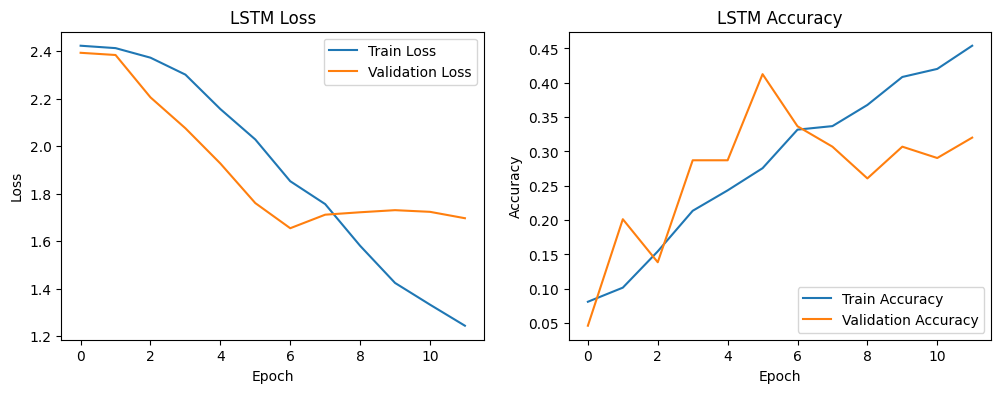

In [ ]:
accuracy_df = pd.DataFrame({'Model': ['LSTM'], 'Accuracy': [lstm_accuracy]})
accuracy_df['Accuracy'] = accuracy_df['Accuracy'].round(4)
print("Model accuracy:")
display(accuracy_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['Accuracy']))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

Report (LSTM):


,precision,recall,f1-score,support
category,,,,
0,0.425500,0.540500,0.476200,74.000000
1,0.391300,0.087400,0.142900,103.000000
2,0.250000,0.066700,0.105300,45.000000
3,0.235600,0.865400,0.370400,52.000000
4,0.351400,0.577800,0.437000,45.000000
5,0.266700,0.129000,0.173900,31.000000
6,0.309400,0.788700,0.444400,71.000000
7,0.300000,0.054500,0.092300,55.000000
8,0.000000,0.000000,0.000000,33.000000


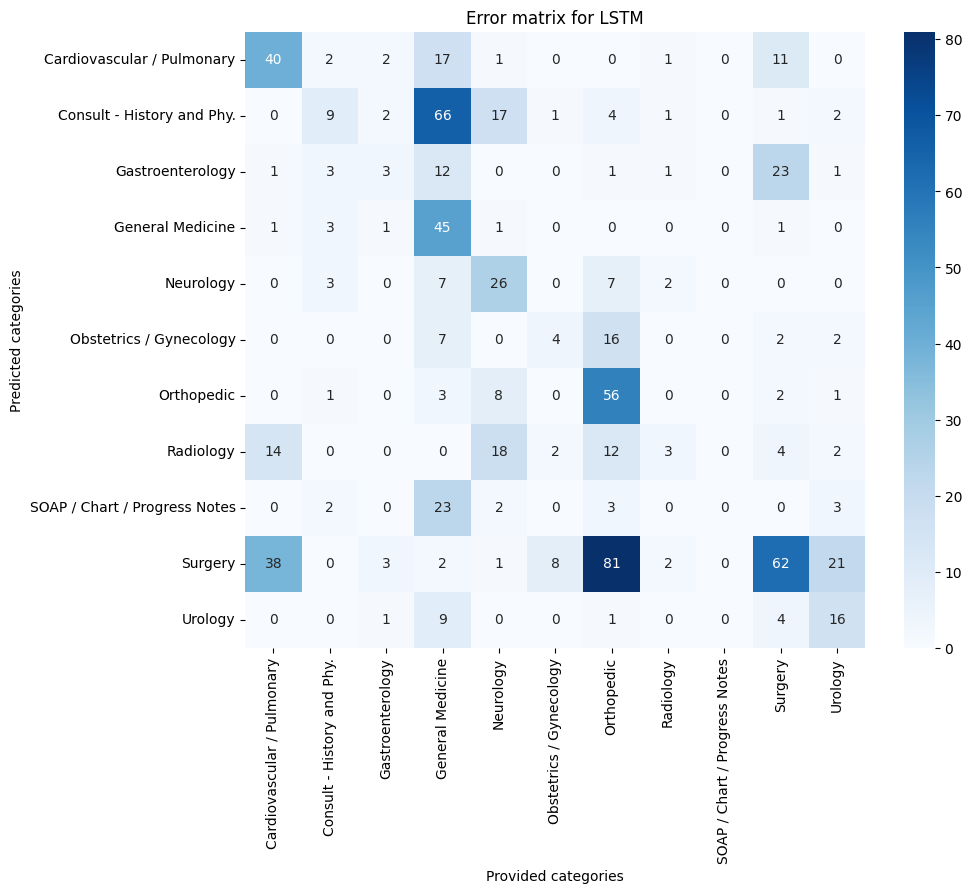

Model LSTM saved


In [ ]:
y_pred_lstm = model_lstm.predict(X_test_pad).argmax(axis=1)
y_true_lstm = y_test

report = classification_report(y_true_lstm, y_pred_lstm, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (LSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for LSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

model_lstm.save('lstm_model.h5')
print("Model LSTM saved")

##### biLSTM

In [ ]:
model_bilstm = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# deal with the class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train_one_hot.argmax(axis=1)
)
class_weight_dict = dict(enumerate(class_weights))

model_bilstm.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=5e-5, mode='min')
history_bilstm = model_bilstm.fit(X_train_pad, y_train_one_hot, epochs=25, batch_size=128,
                             validation_split=0.1, callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict)

loss_bilstm, bilstm_accuracy = model_bilstm.evaluate(X_test_pad, y_test_one_hot, verbose=0)

Epoch 1/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.0587 - loss: 2.4241 - val_accuracy: 0.0495 - val_loss: 2.3997 - learning_rate: 0.0010
Epoch 2/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.1046 - loss: 2.4037 - val_accuracy: 0.1155 - val_loss: 2.3626 - learning_rate: 0.0010
Epoch 3/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.1923 - loss: 2.3095 - val_accuracy: 0.2277 - val_loss: 2.0656 - learning_rate: 0.0010
Epoch 4/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.2793 - loss: 2.0873 - val_accuracy: 0.5116 - val_loss: 1.8309 - learning_rate: 0.0010
Epoch 5/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.3182 - loss: 1.8777 - val_accuracy: 0.3036 - val_loss: 1.6989 - learning_rate: 0.0010
Epoch 6/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.3508 - loss: 1.6706 - val_accuracy: 0.3300 - val_loss: 1.7051 - learning_rate: 0.0010
Epoch 7/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.3828 - loss: 1.4784 - val_

Model accuracy:


,Model,Accuracy
0,biLSTM,0.350900


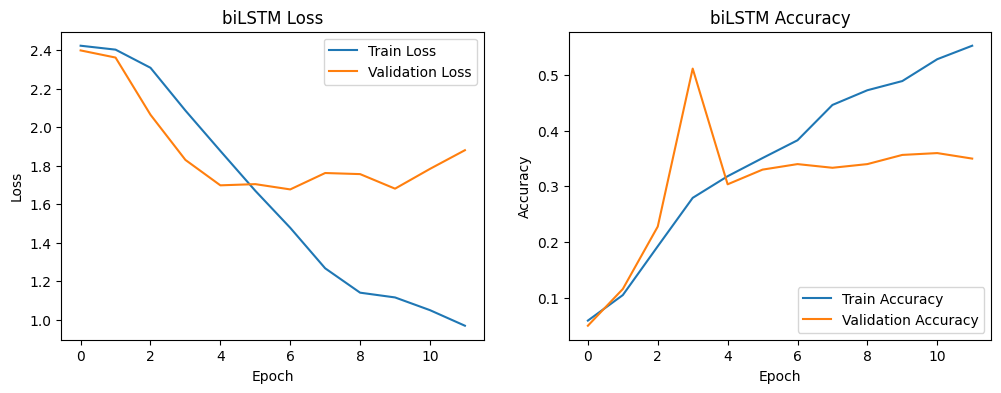

In [ ]:
accuracy_df = pd.DataFrame({'Model': ['biLSTM'], 'Accuracy': [bilstm_accuracy]})
accuracy_df['Accuracy'] = accuracy_df['Accuracy'].round(4)
print("Model accuracy:")
display(accuracy_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['Accuracy']))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_bilstm.history['loss'], label='Train Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.title('biLSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_bilstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('biLSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step

Report (biLSTM):


,precision,recall,f1-score,support
category,,,,
0,0.297500,0.486500,0.369200,74.000000
1,0.368400,0.068000,0.114800,103.000000
2,0.311700,0.533300,0.393400,45.000000
3,0.257700,0.480800,0.335600,52.000000
4,0.262300,0.355600,0.301900,45.000000
5,0.471700,0.806500,0.595200,31.000000
6,0.469400,0.647900,0.544400,71.000000
7,0.307700,0.363600,0.333300,55.000000
8,0.250000,0.333300,0.285700,33.000000


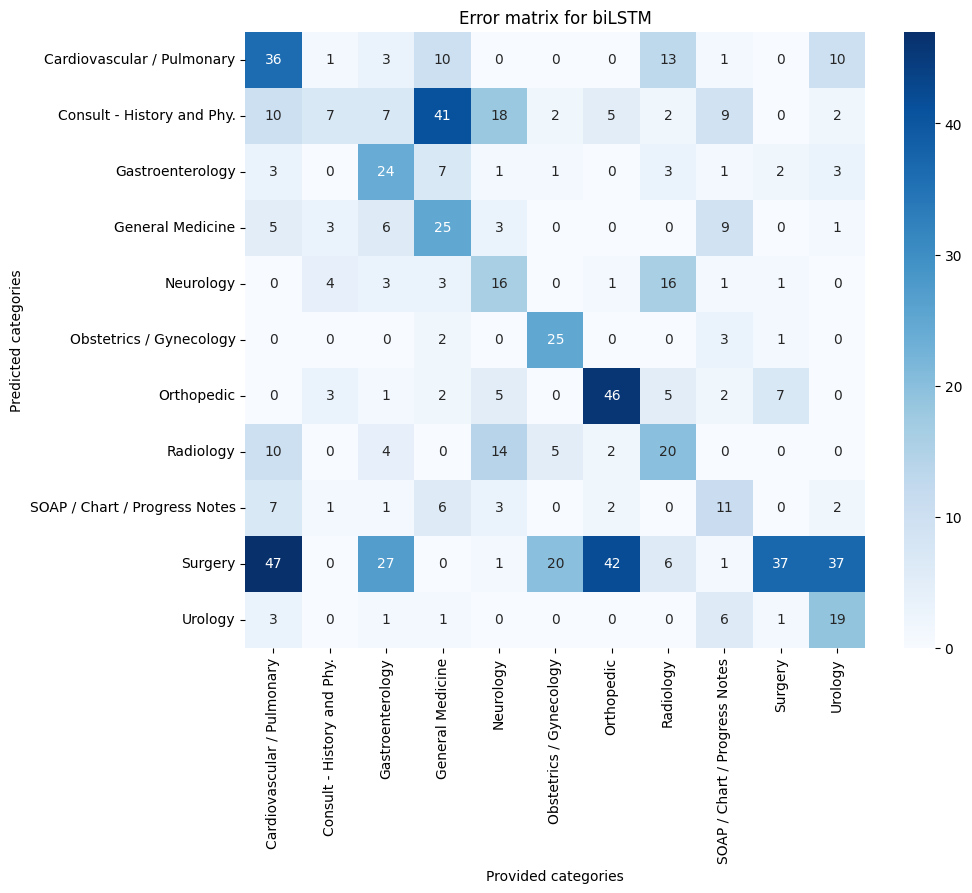

Model biLSTM saved


In [ ]:
y_pred_bilstm = model_bilstm.predict(X_test_pad).argmax(axis=1)
y_true_bilstm = y_test

report = classification_report(y_true_bilstm, y_pred_bilstm, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (biLSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_bilstm, y_pred_bilstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)

plt.title('Error matrix for biLSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

model_bilstm.save('bilstm_model.h5')
print("Model biLSTM saved")

#### Tokenizer + Word2Vec

In [ ]:
EMBED_DIM  = 200      #
LSTM_HIDDEN = 200      #
NUM_FILTERS = 128      #
KERNEL_SIZES = [2,3,4] #
DROPOUT   = 0.5
NUM_CLASSES = df_subset['label'].unique()
MAX_LEN   = 100      #
BATCH_SIZE  = 64
EPOCHS    = 30
LR      = 1e-3     #

In [ ]:
def build_vocab(tokenized_corpus: list[list[str]], min_freq: int = 2) -> dict:
    counter = Counter(w for sent in tokenized_corpus for w in sent)
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for w, freq in counter.items():
        if freq >= min_freq:
            vocab[w] = len(vocab)
    return vocab


def train_word2vec(tokenized_corpus: list[list[str]],
                   vector_size: int = 200,
                   window: int = 5,
                   min_count: int = 2) -> tuple[Word2Vec, Word2Vec]:
    """Train Skip-Gram or CBOW"""
    # sg=1 -> Skip-Gram;  sg=0 -> CBOW
    skipgram = Word2Vec(tokenized_corpus, vector_size=vector_size,
                        window=window, min_count=min_count, sg=1,
                        workers=4, epochs=10)
    cbow = Word2Vec(tokenized_corpus, vector_size=vector_size,
                    window=window, min_count=min_count, sg=0,
                    workers=4, epochs=10)
    return skipgram, cbow


def build_embedding_matrix(vocab: dict, w2v_model: Word2Vec,
                            vector_size: int = 200) -> np.ndarray:
    """Map gensim Word2Vec weights to vocab indices"""
    matrix = np.zeros((len(vocab), vector_size), dtype=np.float32)
    for word, idx in vocab.items():
        if word in w2v_model.wv:
            matrix[idx] = w2v_model.wv[word]
        else:
            matrix[idx] = np.random.normal(0, 0.1, vector_size)
    return matrix


class TextDataset(Dataset):
    def __init__(self, texts: list[list[str]], labels: list[int],
                 vocab: dict, max_len: int = 100):
        self.labels = labels
        self.max_len = max_len
        self.data = [self._encode(t, vocab) for t in texts]

    def _encode(self, tokens: list[str], vocab: dict) -> list[int]:
        ids = [vocab.get(w, 1) for w in tokens]
        if len(ids) >= self.max_len:
            return ids[:self.max_len]
        return ids + [0] * (self.max_len - len(ids))

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        return (torch.tensor(self.data[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long))

class CNNLSTMModel(nn.Module):
    """
    Layer 1 : Embedding (Word2Vec initialization)
    Layer 2 : CNN  — Conv1d + Max Pooling
    Layer 3 : LSTM
    Layer 4 : Softmax
    """

    def __init__(self,
                 vocab_size: int,
                 embed_dim: int = 200,
                 num_filters: int = 128,
                 kernel_sizes: list[int] = None,
                 lstm_hidden: int = 200,
                 num_classes: int = 12,
                 dropout: float = 0.5,
                 pretrained_embeddings: np.ndarray = None):
        super().__init__()

        if kernel_sizes is None:
            kernel_sizes = [2, 3, 4]

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(
                torch.from_numpy(pretrained_embeddings))

        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(embed_dim, num_filters,
                          kernel_size=k, padding=k // 2),
                nn.ReLU()
            ) for k in kernel_sizes
        ])
        cnn_out_dim = num_filters * len(kernel_sizes)

        self.lstm = nn.LSTM(input_size=cnn_out_dim,
                            hidden_size=lstm_hidden,
                            num_layers=1,
                            batch_first=True,
                            bidirectional=False)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (batch, seq_len)
        """
        # Embedding: (batch, seq_len, embed_dim)
        emb = self.embedding(x)

        # CNN requires (batch, embed_dim, seq_len)
        emb_t = emb.permute(0, 2, 1)

        # multi convs (different kernel sizes) + Max Pooling → (batch, num_filters) × len(kernel_sizes)
        pooled = []
        for conv in self.convs:
            c = conv(emb_t)                 # (batch, num_filters, seq_len')
            p = torch.max(c, dim=2).values         # (batch, num_filters)  Max Pooling
            pooled.append(p)

        # concate different kernel results (batch, cnn_out_dim)
        cnn_out = torch.cat(pooled, dim=1)

        # simplier method：put cnn_out series as length = 1 into LSTM
        lstm_in = cnn_out.unsqueeze(1)             # (batch, 1, cnn_out_dim)
        lstm_out, _ = self.lstm(lstm_in)            # (batch, 1, lstm_hidden)
        lstm_feat = lstm_out[:, -1, :]            # (batch, lstm_hidden)

        out = self.dropout(lstm_feat)
        logits = self.fc(out)                  # (batch, num_classes)
        return logits


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total


In [ ]:
X_train_tokens = [text.split() for text in X_train]
X_test_tokens = [text.split() for text in X_test]

# build vocabulary
vocab = build_vocab(X_train_tokens)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# train Word2Vec (skip-gram chosen for this example)
# using a combined corpus for better word embeddings, then restricting to train_vocab
# combined_tokens = X_train_tokens + X_test_tokens # Combine for more robust embeddings
# skipgram_model, _ = train_word2vec(combined_tokens, vector_size=EMBED_DIM, window=5, min_count=2)
skipgram_model, _ = train_word2vec(X_train_tokens, vector_size=EMBED_DIM, window=5, min_count=2)

# build embedding matrix
pretrained_embeddings = build_embedding_matrix(vocab, skipgram_model, vector_size=EMBED_DIM)
print(f"Shape of pretrained_embeddings: {pretrained_embeddings.shape}")

Vocabulary size: 14689
Shape of pretrained_embeddings: (14689, 200)


##### LSTM

In [ ]:
# Re-tokenize and pad data for Keras model with consistent parameters
# Use the same Tokenizer setup as before for consistency with previous Keras models
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to MAX_LEN (100) to match the Word2Vec embedding dimension
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# Ensure y_train_one_hot and y_test_one_hot are up-to-date with current y_train, y_test
num_classes = len(np.unique(y_train))
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

print(f"Shape of X_train_pad: {X_train_pad.shape}")
print(f"Shape of X_test_pad: {X_test_pad.shape}")
print(f"Shape of y_train_one_hot: {y_train_one_hot.shape}")
print(f"Shape of y_test_one_hot: {y_test_one_hot.shape}")

Shape of X_train_pad: (3028, 100)
Shape of X_test_pad: (758, 100)
Shape of y_train_one_hot: (3028, 11)
Shape of y_test_one_hot: (758, 11)


In [ ]:
# Define the Keras LSTM model with Word2Vec embeddings
model_lstm = Sequential([
    Embedding(
        input_dim=vocab_size,  # Use vocabulary size from Word2Vec
        output_dim=EMBED_DIM,  # Use embedding dimension from Word2Vec
        weights=[pretrained_embeddings], # Initialize with pretrained Word2Vec weights
        input_length=MAX_LEN, # Specify input length
        trainable=False        # Set to False to keep embeddings fixed, True to fine-tune
    ),
    SpatialDropout1D(0.3),
    LSTM(64, return_sequences=True),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# Deal with the class imbalance using computed class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train_one_hot.argmax(axis=1)
)
class_weight_dict = dict(enumerate(class_weights))

model_lstm.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

model_lstm.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=5e-5, mode='min')
history_lstm = model_lstm.fit(X_train_pad, y_train_one_hot, epochs=25, batch_size=128,
                             validation_split=0.1, callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict)

loss_lstm, lstm_accuracy = model_lstm.evaluate(X_test_pad, y_test_one_hot, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,937,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,937,800 (11.21 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,937,800 (11.21 MB)

Epoch 1/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.0793 - loss: 2.4469 - val_accuracy: 0.2508 - val_loss: 2.3557 - learning_rate: 0.0010
Epoch 2/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1130 - loss: 2.4235 - val_accuracy: 0.2673 - val_loss: 2.3498 - learning_rate: 0.0010
Epoch 3/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1200 - loss: 2.4048 - val_accuracy: 0.3168 - val_loss: 2.3022 - learning_rate: 0.0010
Epoch 4/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1611 - loss: 2.3636 - val_accuracy: 0.3498 - val_loss: 2.2269 - learning_rate: 0.0010
Epoch 5/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2000 - loss: 2.3129 - val_accuracy: 0.4488 - val_loss: 2.1326 - learning_rate: 0.0010
Epoch 6/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2327 - loss: 2.2650 - val_accuracy: 0.4389 - val_loss: 2.0593 - learning_rate: 0.0010
Epoch 7/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2396 - loss: 2.2154 - val_acc

Model accuracy:


,Model,Accuracy
0,LSTM,0.364100


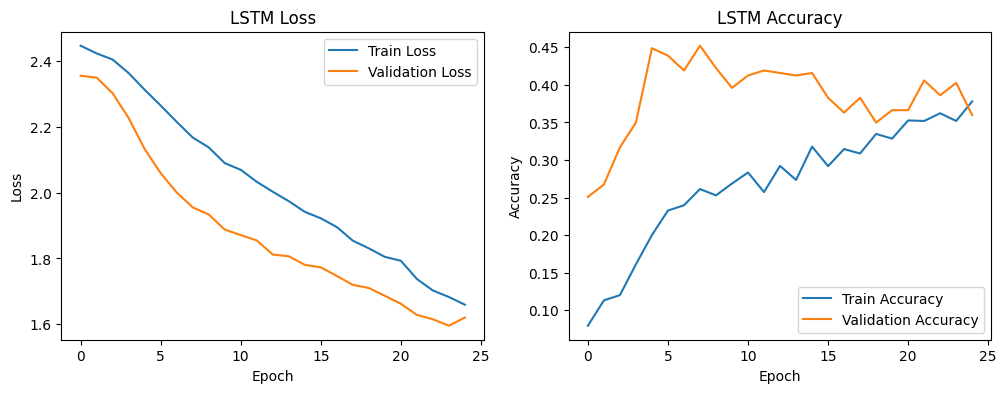

In [ ]:
accuracy_df = pd.DataFrame({'Model': ['LSTM'], 'Accuracy': [lstm_accuracy]})
accuracy_df['Accuracy'] = accuracy_df['Accuracy'].round(4)
print("Model accuracy:")
display(accuracy_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['Accuracy']))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Report (LSTM):


,precision,recall,f1-score,support
category,,,,
0,0.381000,0.324300,0.350400,74.000000
1,0.387100,0.466000,0.422900,103.000000
2,0.179700,0.511100,0.265900,45.000000
3,0.243600,0.365400,0.292300,52.000000
4,0.289500,0.244400,0.265100,45.000000
5,0.459500,0.548400,0.500000,31.000000
6,0.350000,0.197200,0.252300,71.000000
7,0.491200,0.509100,0.500000,55.000000
8,0.391300,0.545500,0.455700,33.000000


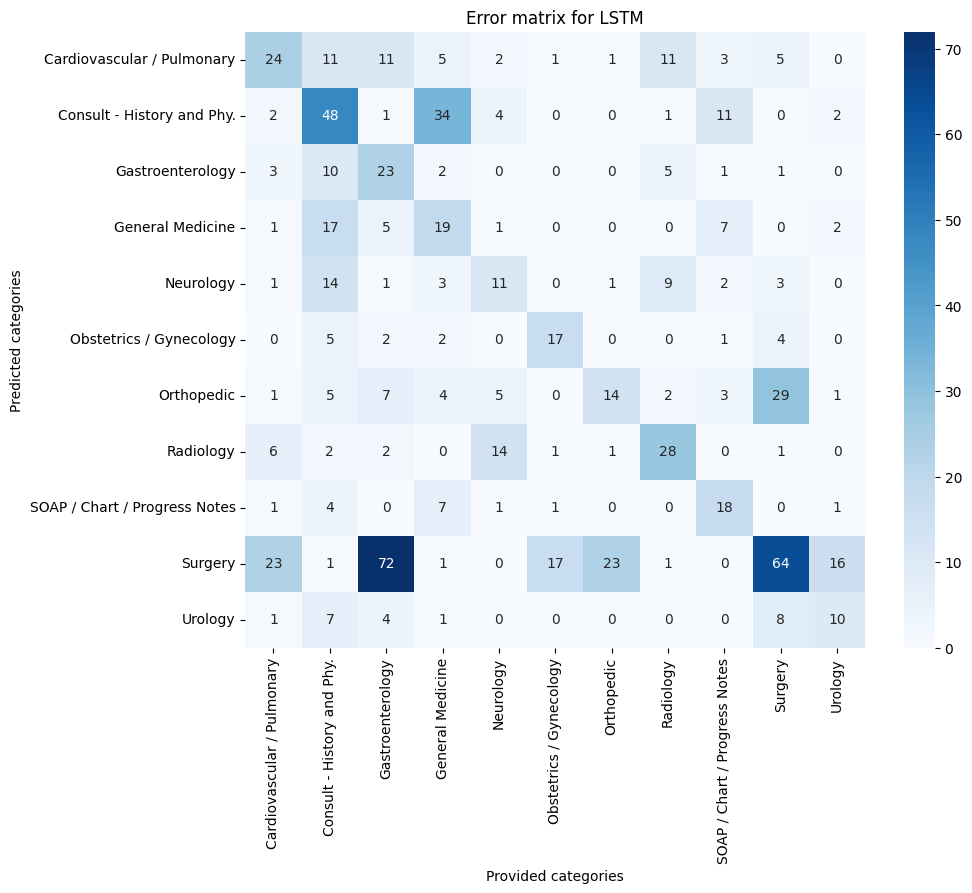

Model LSTM saved


In [ ]:
y_pred_lstm = model_lstm.predict(X_test_pad).argmax(axis=1)
y_true_lstm = y_test

report = classification_report(y_true_lstm, y_pred_lstm, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (LSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for LSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

model_lstm.save('lstm_model.h5')
print("Model LSTM saved")

##### CNN + LSTM

In [ ]:
# ensure labels are integers
y_train_list = y_train.tolist()
y_test_list = y_test.tolist()

# create datasets and dataloaders
train_dataset = TextDataset(X_train_tokens, y_train_list, vocab, max_len=MAX_LEN)
test_dataset = TextDataset(X_test_tokens, y_test_list, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Number of training batches: 48
Number of testing batches: 12


In [ ]:
# determine the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ensure num_classes is correctly set
num_classes_actual = len(np.unique(y_train))

model_cnn_lstm_w2v = CNNLSTMModel(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    lstm_hidden=LSTM_HIDDEN,
    num_classes=num_classes_actual,
    dropout=DROPOUT,
    pretrained_embeddings=pretrained_embeddings
).to(device)

print(model_cnn_lstm_w2v)

optimizer = optim.Adam(model_cnn_lstm_w2v.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

Using device: cuda
CNNLSTMModel(
  (embedding): Embedding(14689, 200, padding_idx=0)
  (convs): ModuleList(
    (0): Sequential(
      (0): Conv1d(200, 128, kernel_size=(2,), stride=(1,), padding=(1,))
      (1): ReLU()
    )
    (1): Sequential(
      (0): Conv1d(200, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): ReLU()
    )
    (2): Sequential(
      (0): Conv1d(200, 128, kernel_size=(4,), stride=(1,), padding=(2,))
      (1): ReLU()
    )
  )
  (lstm): LSTM(384, 200, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=200, out_features=11, bias=True)
)


In [ ]:
# training loop
print("Starting training...")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model_cnn_lstm_w2v, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# report final performance
final_train_loss, final_train_acc = evaluate(model_cnn_lstm_w2v, train_loader, criterion, device)
final_test_loss, final_test_acc = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)

print("\n--- Training Finished ---")
print(f"Final Train Accuracy: {final_train_acc:.4f}, Final Train Loss: {final_train_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}, Final Test Loss: {final_test_loss:.4f}")

Starting training...
Epoch 1/30 | Train Loss: 1.9667, Train Acc: 0.3702 | Val Loss: 1.6863, Val Acc: 0.4631
Epoch 2/30 | Train Loss: 1.5275, Train Acc: 0.4693 | Val Loss: 1.4476, Val Acc: 0.4578
Epoch 3/30 | Train Loss: 1.2677, Train Acc: 0.4927 | Val Loss: 1.3225, Val Acc: 0.4354
Epoch 4/30 | Train Loss: 1.1030, Train Acc: 0.5149 | Val Loss: 1.2759, Val Acc: 0.3931
Epoch 5/30 | Train Loss: 0.9971, Train Acc: 0.5317 | Val Loss: 1.3226, Val Acc: 0.3628
Epoch 6/30 | Train Loss: 0.9364, Train Acc: 0.5479 | Val Loss: 1.3867, Val Acc: 0.3654
Epoch 7/30 | Train Loss: 0.8688, Train Acc: 0.5651 | Val Loss: 1.4622, Val Acc: 0.3061
Epoch 8/30 | Train Loss: 0.8464, Train Acc: 0.5730 | Val Loss: 1.5181, Val Acc: 0.2942
Epoch 9/30 | Train Loss: 0.8014, Train Acc: 0.5842 | Val Loss: 1.5728, Val Acc: 0.2427
Epoch 10/30 | Train Loss: 0.7788, Train Acc: 0.5832 | Val Loss: 1.6691, Val Acc: 0.2625
Epoch 11/30 | Train Loss: 0.7676, Train Acc: 0.5964 | Val Loss: 1.7232, Val Acc: 0.2559
Epoch 12/30 | Train 


Report (Word2Vec + CNN + LSTM):


,precision,recall,f1-score,support
category,,,,
0,0.166700,0.175700,0.171100,74.000000
1,0.263600,0.281600,0.272300,103.000000
2,0.075000,0.066700,0.070600,45.000000
3,0.133300,0.153800,0.142900,52.000000
4,0.102000,0.111100,0.106400,45.000000
5,0.045500,0.032300,0.037700,31.000000
6,0.136400,0.126800,0.131400,71.000000
7,0.230800,0.218200,0.224300,55.000000
8,0.172400,0.151500,0.161300,33.000000


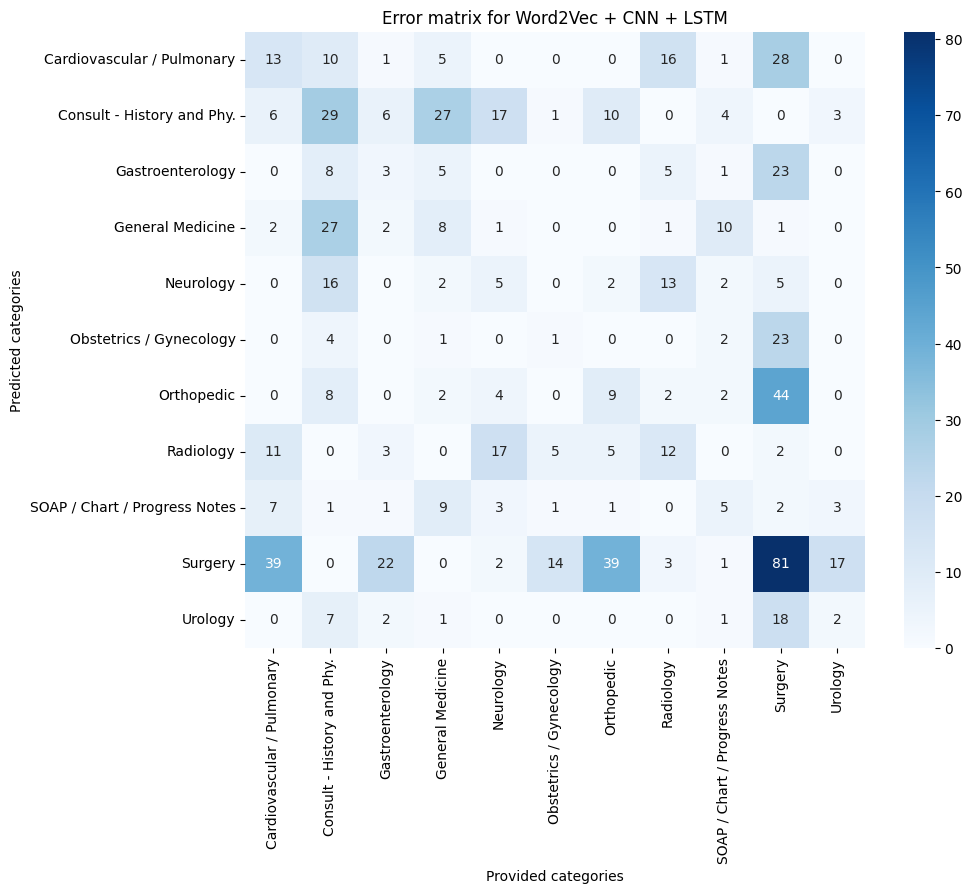

In [ ]:
# get predictions from model
model_cnn_lstm_w2v.eval()  # evaluation mode
y_true_w2v = []
y_pred_w2v = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        logits = model_cnn_lstm_w2v(x_batch)
        predictions = torch.argmax(logits, dim=1).cpu().numpy()
        y_true_w2v.extend(y_batch.cpu().numpy())
        y_pred_w2v.extend(predictions)

# convert to numpy arrays
y_true_w2v = np.array(y_true_w2v)
y_pred_w2v = np.array(y_pred_w2v)

report = classification_report(y_true_w2v, y_pred_w2v, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (Word2Vec + CNN + LSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_w2v, y_pred_w2v)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for Word2Vec + CNN + LSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

### GroupShuffleSplit



In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# set each identical transcription as group
train_idx, test_idx = next(gss.split(df_subset, groups=df_subset['processed_data']))

train_df = df_subset.iloc[train_idx]
test_df  = df_subset.iloc[test_idx]

train_trans = set(train_df['processed_data'])
test_trans  = set(test_df['processed_data'])
print(f"# of rows in train set: {len(train_df)}, # of rows in test set: {len(test_df)}")
print(f"overlap transcription: {len(train_trans & test_trans)}")

X_train, y_train = train_df['processed_data'], train_df['label']
X_test, y_test = test_df['processed_data'], test_df['label']

# of rows in train set: 3017, # of rows in test set: 769
overlap transcription: 0


#### Tokenizer + pad_sequences

In [ ]:
# tokenize
max_words = 20000
max_len = 500
tokenizer_dl = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(X_train)

X_train_seq = tokenizer_dl.texts_to_sequences(X_train)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

In [ ]:
# ensure y_train_one_hot and y_test_one_hot are up-to-date
num_classes = len(y_train.unique())
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)


In [ ]:
# create a stratified validation split from the training data
X_train_sub, X_val_pad, y_train_sub_one_hot, y_val_one_hot = train_test_split(
    X_train_pad, y_train_one_hot, test_size=0.25, random_state=42, stratify=y_train_one_hot
)

print(f"Number of training samples for sub-training: {len(X_train_sub)}")
print(f"Number of validation samples: {len(X_val_pad)}")

Number of training samples for sub-training: 2262
Number of validation samples: 755


##### LSTM

In [ ]:
num_classes = len(y_train.unique())

model_lstm = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    SpatialDropout1D(0.3),
    LSTM(64, return_sequences=True),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# deal with the class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train_one_hot.argmax(axis=1)
)
class_weight_dict = dict(enumerate(class_weights))

model_lstm.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=5e-5, mode='min')
history_lstm = model_lstm.fit(X_train_sub, y_train_sub_one_hot, epochs=25, batch_size=128,
                             validation_data=(X_val_pad, y_val_one_hot), callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict)

loss_lstm, lstm_accuracy = model_lstm.evaluate(X_test_pad, y_test_one_hot, verbose=0)

Epoch 1/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.0778 - loss: 2.4002 - val_accuracy: 0.0861 - val_loss: 2.3921 - learning_rate: 0.0010
Epoch 2/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.1026 - loss: 2.3947 - val_accuracy: 0.1007 - val_loss: 2.3899 - learning_rate: 0.0010
Epoch 3/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.1600 - loss: 2.3781 - val_accuracy: 0.3351 - val_loss: 2.3501 - learning_rate: 0.0010
Epoch 4/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.1945 - loss: 2.2933 - val_accuracy: 0.1417 - val_loss: 2.1550 - learning_rate: 0.0010
Epoch 5/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.2166 - loss: 2.1715 - val_accuracy: 0.2821 - val_loss: 2.0688 - learning_rate: 0.0010
Epoch 6/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.2352 - loss: 2.0451 - val_accuracy: 0.2397 - val_loss: 2.0296 - learning_rate: 0.0010
Epoch 7/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.2308 - loss: 1.9342 - val_acc

Model accuracy:


,Model,Accuracy
0,LSTM,0.435600


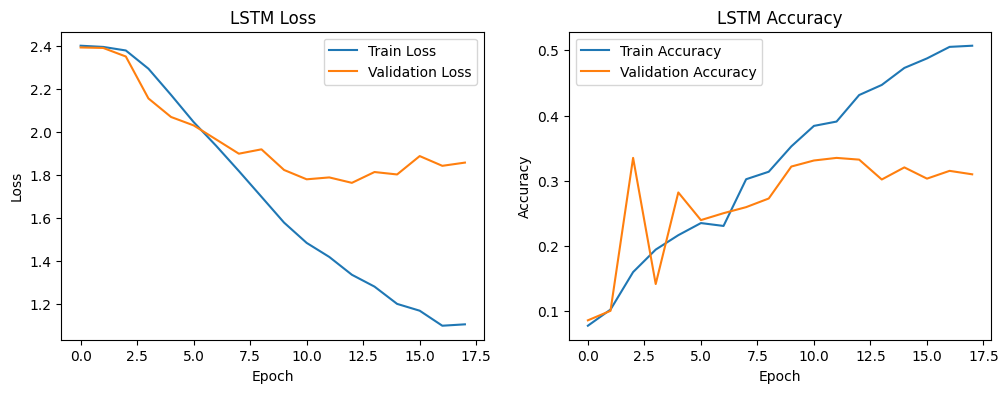

In [ ]:
accuracy_df = pd.DataFrame({'Model': ['LSTM'], 'Accuracy': [lstm_accuracy]})
accuracy_df['Accuracy'] = accuracy_df['Accuracy'].round(4)
print("Model accuracy:")
display(accuracy_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['Accuracy']))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

Report (LSTM):


,precision,recall,f1-score,support
category,,,,
0,0.463900,0.661800,0.545500,68.000000
1,0.423100,0.351100,0.383700,94.000000
2,0.444400,0.711100,0.547000,45.000000
3,0.284200,0.509400,0.364900,53.000000
4,0.377000,0.547600,0.446600,42.000000
5,0.456500,0.724100,0.560000,29.000000
6,0.466200,0.747000,0.574100,83.000000
7,0.566700,0.246400,0.343400,69.000000
8,0.347800,0.400000,0.372100,40.000000


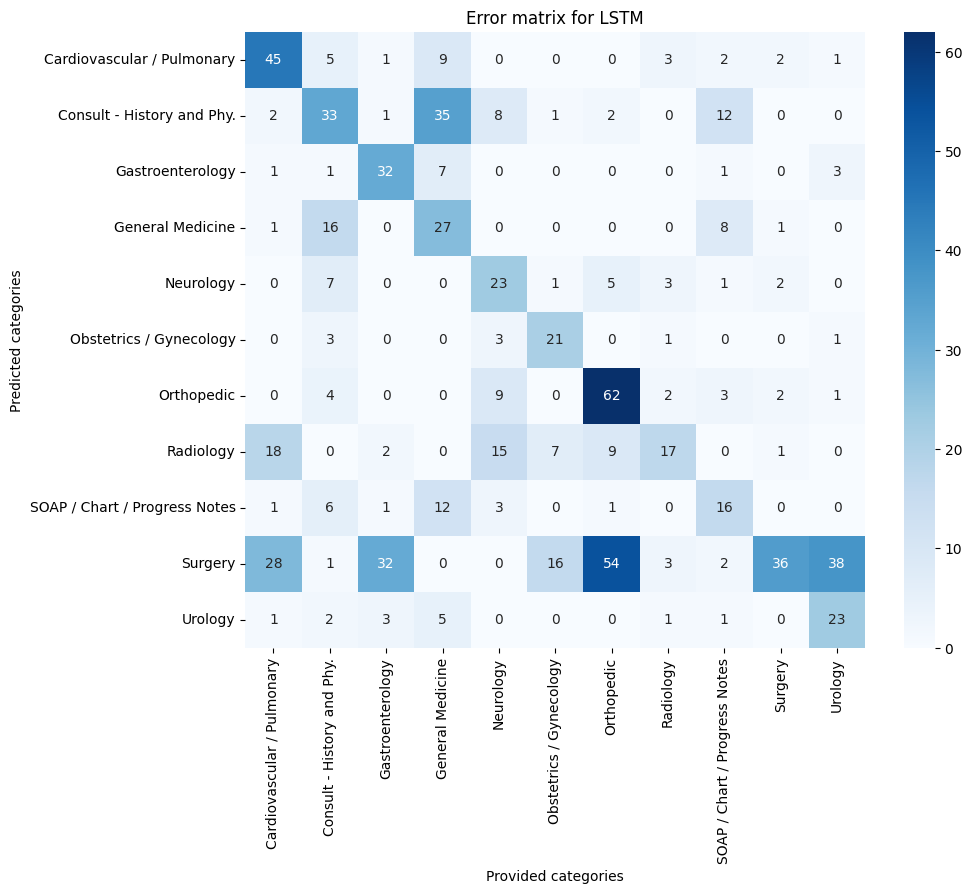

Model LSTM saved


In [ ]:
y_pred_lstm = model_lstm.predict(X_test_pad).argmax(axis=1)
y_true_lstm = y_test

report = classification_report(y_true_lstm, y_pred_lstm, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (LSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for LSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

model_lstm.save('lstm_model.h5')
print("Model LSTM saved")

##### biLSTM

In [ ]:
model_bilstm = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# deal with the class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train_one_hot.argmax(axis=1)
)
class_weight_dict = dict(enumerate(class_weights))

model_bilstm.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=5e-5, mode='min')
history_bilstm = model_bilstm.fit(X_train_sub, y_train_sub_one_hot, epochs=25, batch_size=128,
                             validation_data=(X_val_pad, y_val_one_hot), callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict)

loss_bilstm, bilstm_accuracy = model_bilstm.evaluate(X_test_pad, y_test_one_hot, verbose=0)

Epoch 1/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.0805 - loss: 2.3973 - val_accuracy: 0.1894 - val_loss: 2.3934 - learning_rate: 0.0010
Epoch 2/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.1605 - loss: 2.3798 - val_accuracy: 0.2543 - val_loss: 2.3621 - learning_rate: 0.0010
Epoch 3/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.2157 - loss: 2.3242 - val_accuracy: 0.2066 - val_loss: 2.1314 - learning_rate: 0.0010
Epoch 4/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.2321 - loss: 2.1542 - val_accuracy: 0.2252 - val_loss: 1.9530 - learning_rate: 0.0010
Epoch 5/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.2440 - loss: 2.0108 - val_accuracy: 0.2781 - val_loss: 1.9214 - learning_rate: 0.0010
Epoch 6/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.2843 - loss: 1.8133 - val_accuracy: 0.2649 - val_loss: 1.8780 - learning_rate: 0.0010
Epoch 7/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.3338 - loss: 1.6564 - val_acc

Model accuracy:


,Model,Accuracy
0,biLSTM,0.442100


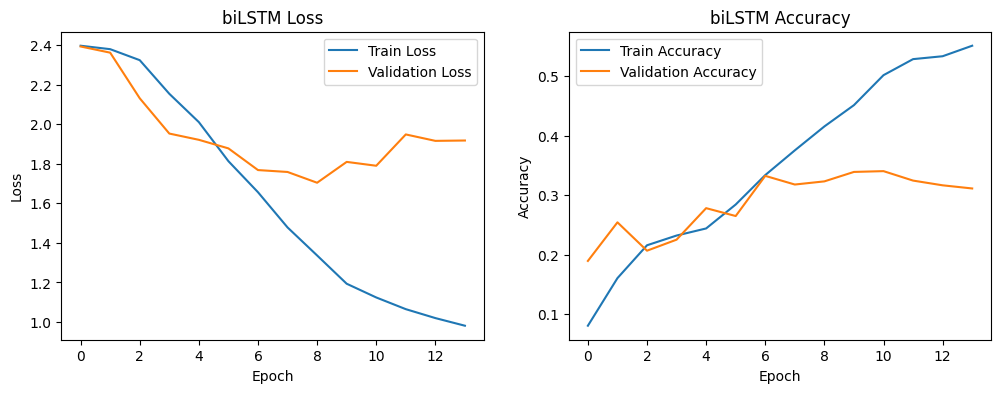

In [ ]:
accuracy_df = pd.DataFrame({'Model': ['biLSTM'], 'Accuracy': [bilstm_accuracy]})
accuracy_df['Accuracy'] = accuracy_df['Accuracy'].round(4)
print("Model accuracy:")
display(accuracy_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['Accuracy']))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_bilstm.history['loss'], label='Train Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.title('biLSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_bilstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('biLSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

Report (biLSTM):


,precision,recall,f1-score,support
category,,,,
0,0.433700,0.529400,0.476800,68.000000
1,0.473700,0.287200,0.357600,94.000000
2,0.347200,0.555600,0.427400,45.000000
3,0.303000,0.377400,0.336100,53.000000
4,0.360000,0.214300,0.268700,42.000000
5,0.344800,0.689700,0.459800,29.000000
6,0.476600,0.734900,0.578200,83.000000
7,0.459000,0.405800,0.430800,69.000000
8,0.318200,0.525000,0.396200,40.000000


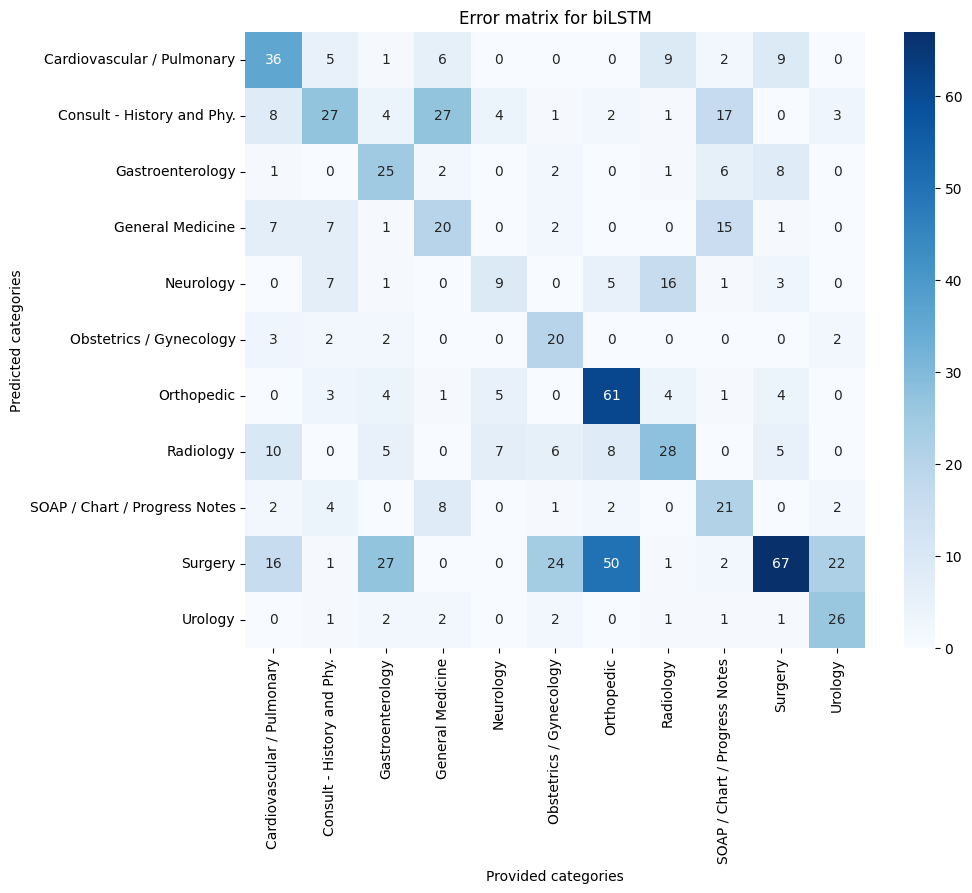

Model biLSTM saved


In [ ]:
y_pred_bilstm = model_bilstm.predict(X_test_pad).argmax(axis=1)
y_true_bilstm = y_test

report = classification_report(y_true_bilstm, y_pred_bilstm, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (biLSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_bilstm, y_pred_bilstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for biLSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

model_lstm.save('bilstm_model.h5')
print("Model biLSTM saved")

#### Tokenizer + Word2Vec

##### LSTM

In [ ]:
# Re-tokenize and pad data for Keras model with consistent parameters
# Use the same Tokenizer setup as before for consistency with previous Keras models
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to MAX_LEN (100) to match the Word2Vec embedding dimension
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# Ensure y_train_one_hot and y_test_one_hot are up-to-date with current y_train, y_test
num_classes = len(np.unique(y_train))
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

print(f"Shape of X_train_pad: {X_train_pad.shape}")
print(f"Shape of X_test_pad: {X_test_pad.shape}")
print(f"Shape of y_train_one_hot: {y_train_one_hot.shape}")
print(f"Shape of y_test_one_hot: {y_test_one_hot.shape}")

Shape of X_train_pad: (3017, 100)
Shape of X_test_pad: (769, 100)
Shape of y_train_one_hot: (3017, 11)
Shape of y_test_one_hot: (769, 11)


In [ ]:
# Define the Keras LSTM model with Word2Vec embeddings
model_lstm = Sequential([
    Embedding(
        input_dim=vocab_size,  # Use vocabulary size from Word2Vec
        output_dim=EMBED_DIM,  # Use embedding dimension from Word2Vec
        weights=[pretrained_embeddings], # Initialize with pretrained Word2Vec weights
        input_length=MAX_LEN, # Specify input length
        trainable=False        # Set to False to keep embeddings fixed, True to fine-tune
    ),
    SpatialDropout1D(0.3),
    LSTM(64, return_sequences=True),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# Deal with the class imbalance using computed class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train_one_hot.argmax(axis=1)
)
class_weight_dict = dict(enumerate(class_weights))

model_lstm.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

model_lstm.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=5e-5, mode='min')
history_lstm = model_lstm.fit(X_train_pad, y_train_one_hot, epochs=25, batch_size=128,
                             validation_split=0.1, callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict)

loss_lstm, lstm_accuracy = model_lstm.evaluate(X_test_pad, y_test_one_hot, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │     2,937,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_5          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,937,800 (11.21 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,937,800 (11.21 MB)

Epoch 1/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.0972 - loss: 2.4450 - val_accuracy: 0.0033 - val_loss: 2.9184 - learning_rate: 0.0010
Epoch 2/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1215 - loss: 2.3747 - val_accuracy: 0.0099 - val_loss: 3.3638 - learning_rate: 0.0010
Epoch 3/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1160 - loss: 2.3628 - val_accuracy: 0.0066 - val_loss: 3.5529 - learning_rate: 0.0010
Epoch 4/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1602 - loss: 2.3281 - val_accuracy: 0.0099 - val_loss: 3.6776 - learning_rate: 0.0010
Epoch 5/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1860 - loss: 2.2538 - val_accuracy: 0.0066 - val_loss: 4.2560 - learning_rate: 0.0010
Epoch 6/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2593 - loss: 2.1740 - val_accuracy: 0.0066 - val_loss: 4.4460 - learning_rate: 0.0010


Model accuracy:


,Model,Accuracy
0,LSTM,0.267900


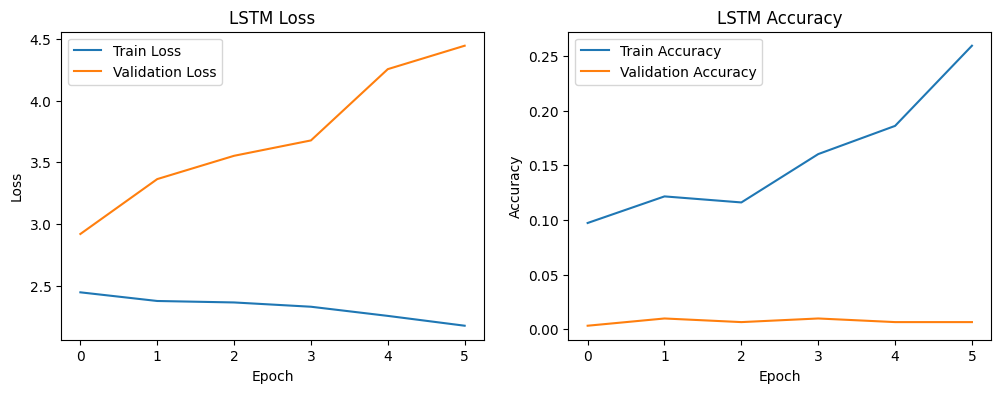

In [ ]:
accuracy_df = pd.DataFrame({'Model': ['LSTM'], 'Accuracy': [lstm_accuracy]})
accuracy_df['Accuracy'] = accuracy_df['Accuracy'].round(4)
print("Model accuracy:")
display(accuracy_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['Accuracy']))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Report (LSTM):


,precision,recall,f1-score,support
category,,,,
0,0.000000,0.000000,0.000000,68.000000
1,0.310300,0.095700,0.146300,94.000000
2,0.000000,0.000000,0.000000,45.000000
3,0.088200,0.226400,0.127000,53.000000
4,0.000000,0.000000,0.000000,42.000000
5,0.041700,0.034500,0.037700,29.000000
6,0.000000,0.000000,0.000000,83.000000
7,0.400000,0.029000,0.054100,69.000000
8,0.000000,0.000000,0.000000,40.000000


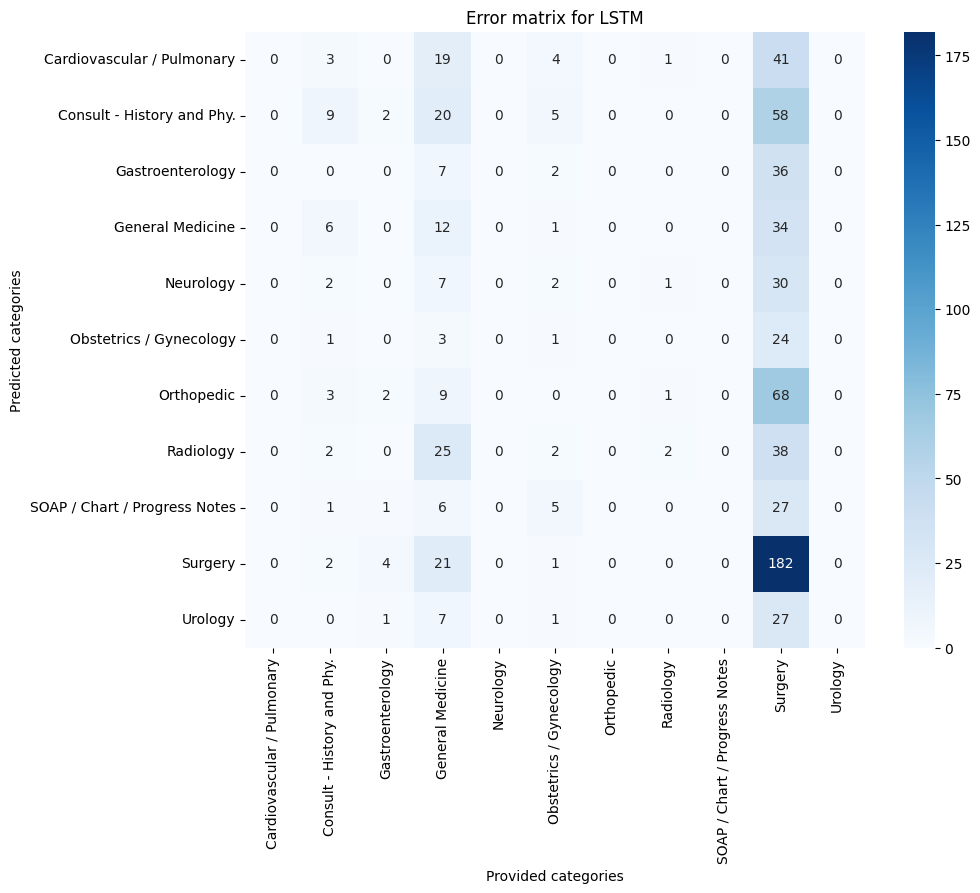

Model LSTM saved


In [ ]:
y_pred_lstm = model_lstm.predict(X_test_pad).argmax(axis=1)
y_true_lstm = y_test

report = classification_report(y_true_lstm, y_pred_lstm, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (LSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for LSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

model_lstm.save('lstm_model.h5')
print("Model LSTM saved")

##### CNN + LSTM

Text classification based on hybrid CNN-LSTM hybrid model

In [ ]:
X_train_tokens = [text.split() for text in X_train]
X_test_tokens = [text.split() for text in X_test]

# build vocabulary
vocab = build_vocab(X_train_tokens)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# train Word2Vec (skip-gram chosen for this example)
# using a combined corpus for better word embeddings, then restricting to train_vocab
# combined_tokens = X_train_tokens + X_test_tokens # Combine for more robust embeddings
# skipgram_model, _ = train_word2vec(combined_tokens, vector_size=EMBED_DIM, window=5, min_count=2)
skipgram_model, _ = train_word2vec(X_train_tokens, vector_size=EMBED_DIM, window=5, min_count=2)

# build embedding matrix
pretrained_embeddings = build_embedding_matrix(vocab, skipgram_model, vector_size=EMBED_DIM)
print(f"Shape of pretrained_embeddings: {pretrained_embeddings.shape}")

Vocabulary size: 14958
Shape of pretrained_embeddings: (14958, 200)


In [ ]:
y_train_list = y_train.tolist()
y_test_list = y_test.tolist()

train_dataset = TextDataset(X_train_tokens, y_train_list, vocab, max_len=MAX_LEN)
test_dataset = TextDataset(X_test_tokens, y_test_list, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Number of training batches: 48
Number of testing batches: 13


In [ ]:
# determine the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ensure num_classes is correctly set
num_classes_actual = len(np.unique(y_train))

model_cnn_lstm_w2v = CNNLSTMModel(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    lstm_hidden=LSTM_HIDDEN,
    num_classes=num_classes_actual,
    dropout=DROPOUT,
    pretrained_embeddings=pretrained_embeddings
).to(device)

print(model_cnn_lstm_w2v)

optimizer = optim.Adam(model_cnn_lstm_w2v.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

Using device: cuda
CNNLSTMModel(
  (embedding): Embedding(14958, 200, padding_idx=0)
  (convs): ModuleList(
    (0): Sequential(
      (0): Conv1d(200, 128, kernel_size=(2,), stride=(1,), padding=(1,))
      (1): ReLU()
    )
    (1): Sequential(
      (0): Conv1d(200, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): ReLU()
    )
    (2): Sequential(
      (0): Conv1d(200, 128, kernel_size=(4,), stride=(1,), padding=(2,))
      (1): ReLU()
    )
  )
  (lstm): LSTM(384, 200, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=200, out_features=11, bias=True)
)


In [ ]:
# training
print("Starting training...")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model_cnn_lstm_w2v, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# report final performance
final_train_loss, final_train_acc = evaluate(model_cnn_lstm_w2v, train_loader, criterion, device)
final_test_loss, final_test_acc = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)

print("\n--- Training Finished ---")
print(f"Final Train Accuracy: {final_train_acc:.4f}, Final Train Loss: {final_train_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}, Final Test Loss: {final_test_loss:.4f}")

Starting training...
Epoch 1/30 | Train Loss: 1.9768, Train Acc: 0.3709 | Val Loss: 1.7554, Val Acc: 0.4200
Epoch 2/30 | Train Loss: 1.5623, Train Acc: 0.4839 | Val Loss: 1.4478, Val Acc: 0.4772
Epoch 3/30 | Train Loss: 1.3376, Train Acc: 0.4780 | Val Loss: 1.3008, Val Acc: 0.4863
Epoch 4/30 | Train Loss: 1.1857, Train Acc: 0.4886 | Val Loss: 1.2112, Val Acc: 0.4941
Epoch 5/30 | Train Loss: 1.0937, Train Acc: 0.4945 | Val Loss: 1.1675, Val Acc: 0.4928
Epoch 6/30 | Train Loss: 1.0107, Train Acc: 0.5164 | Val Loss: 1.1123, Val Acc: 0.5085
Epoch 7/30 | Train Loss: 0.9456, Train Acc: 0.5217 | Val Loss: 1.1340, Val Acc: 0.5085
Epoch 8/30 | Train Loss: 0.8999, Train Acc: 0.5353 | Val Loss: 1.1189, Val Acc: 0.5059
Epoch 9/30 | Train Loss: 0.8830, Train Acc: 0.5257 | Val Loss: 1.1131, Val Acc: 0.4993
Epoch 10/30 | Train Loss: 0.8564, Train Acc: 0.5346 | Val Loss: 1.0635, Val Acc: 0.5228
Epoch 11/30 | Train Loss: 0.8343, Train Acc: 0.5323 | Val Loss: 1.0671, Val Acc: 0.5163
Epoch 12/30 | Train 


Report (Word2Vec + CNN + LSTM):


,precision,recall,f1-score,support
category,,,,
0,0.512200,0.617600,0.560000,68.000000
1,0.457500,0.744700,0.566800,94.000000
2,0.472700,0.577800,0.520000,45.000000
3,0.419400,0.245300,0.309500,53.000000
4,0.487200,0.452400,0.469100,42.000000
5,0.526300,0.344800,0.416700,29.000000
6,0.500000,0.481900,0.490800,83.000000
7,0.540000,0.391300,0.453800,69.000000
8,0.608700,0.350000,0.444400,40.000000


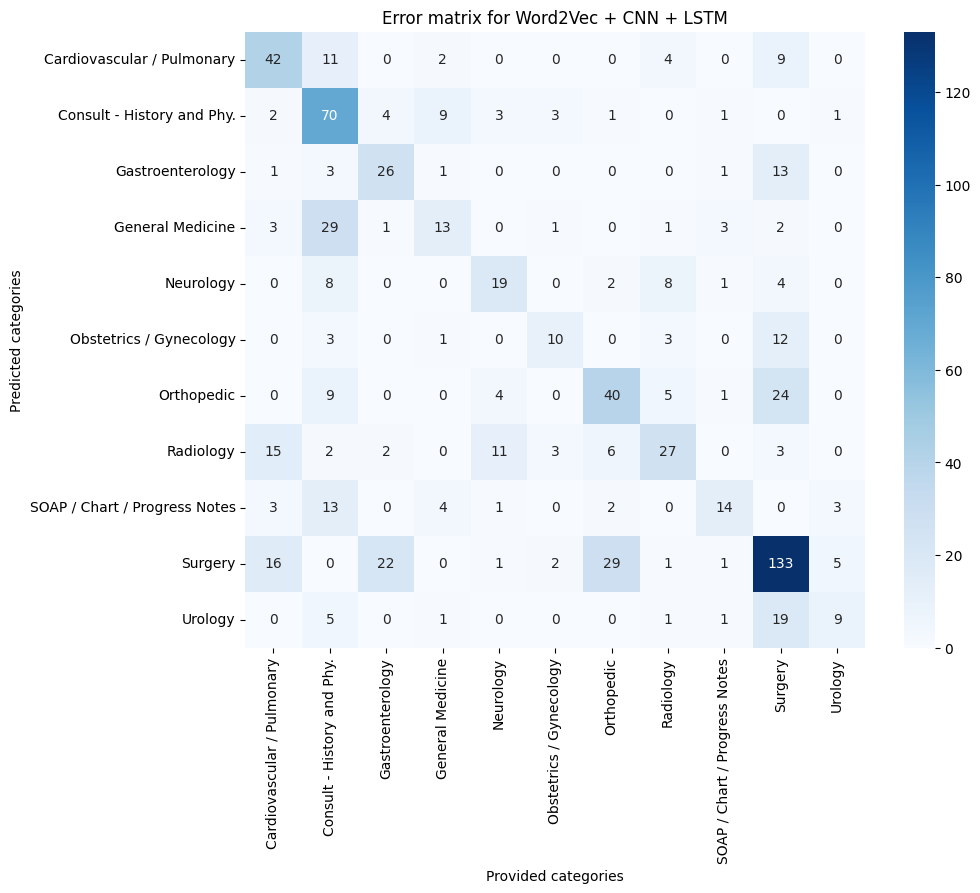

In [ ]:
# get predictions from model
model_cnn_lstm_w2v.eval()  # evaluation mode
y_true_w2v = []
y_pred_w2v = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        logits = model_cnn_lstm_w2v(x_batch)
        predictions = torch.argmax(logits, dim=1).cpu().numpy()
        y_true_w2v.extend(y_batch.cpu().numpy())
        y_pred_w2v.extend(predictions)

# convert to numpy arrays
y_true_w2v = np.array(y_true_w2v)
y_pred_w2v = np.array(y_pred_w2v)

report = classification_report(y_true_w2v, y_pred_w2v, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (Word2Vec + CNN + LSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_w2v, y_pred_w2v)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for Word2Vec + CNN + LSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

In [ ]:
# save CNN-LSTM model as .pkl file
from google.colab import files
import pickle

with open("CNN_LSTM_origin.pkl", "wb") as f:
    pickle.dump(model_cnn_lstm_w2v, f)

files.download("CNN_LSTM_origin.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Data Augmentation 1 (20 categories)

Use mtsamples_augmented.csv (**translation**)

In [ ]:
df = pd.read_csv('mtsamples_augmented.csv')

In [ ]:
df.head()

,description,medical_specialty,sample_name,transcription,keywords,processed_data,label
0,"Bilateral myringotomies, insertion of PE tube...",Surgery,Myringotomy/Tube Insertion,"PREOPERATIVE DIAGNOSES:, Chronic otitis media...","surgery, bilateral myringotomies, insertion of...",preoperative diagnose chronic otitis media eff...,18
1,Insertion of a right brachial artery arterial...,Surgery,Triple Lumen Catheter Insertion,"PREOPERATIVE DIAGNOSES:,1. Hyperpyrexia/leuko...","surgery, hyperpyrexia, leukocytosis, ventilato...",preoperative diagnose hyperpyrexia leukocytosi...,18
2,Fracture reduction with insertion of prosthe...,Surgery,Kyphoplasty & Vertebroplasty,"PREOPERATIVE DIAGNOSES:,1. Pathologic insuffi...","surgery, pathologic insufficiency, vertebrae, ...",preoperative diagnose pathologic insufficiency...,18
3,"Excision dorsal ganglion, right wrist. The ...",Surgery,Dorsal Ganglion - Excision,"PREOPERATIVE DIAGNOSIS:, Dorsal ganglion, rig...","surgery, excision dorsal ganglion, extensor te...",preoperative dorsal ganglion wrist postoperati...,18
4,Artificial rupture of membrane was performed ...,Surgery,Delivery Note - 5,"DELIVERY NOTE: , This is a 30-year-old G7, P5 ...","surgery, perineum, placenta, rupture of membra...",delivery note year old g p female th weeks pre...,18


In [ ]:
classes = df['medical_specialty'].unique()
print(classes)

['Surgery' 'Consult - History and Phy.' 'Cardiovascular / Pulmonary'
 'Orthopedic' 'Radiology' 'General Medicine' 'Gastroenterology'
 'Neurology' 'SOAP / Chart / Progress Notes' 'Urology'
 'Obstetrics / Gynecology' 'Discharge Summary' 'ENT - Otolaryngology'
 'Neurosurgery' 'Hematology - Oncology' 'Ophthalmology' 'Nephrology'
 'Emergency Room Reports' 'Pediatrics - Neonatal' 'Pain Management']


In [ ]:
label_mapping = df[['medical_specialty', 'label']].drop_duplicates().sort_values('label').reset_index(drop=True)

label_distribution = df['label'].value_counts().reset_index()
label_distribution.columns = ['label', 'count']

combined_label_info = pd.merge(label_mapping, label_distribution, on='label')

print("Combined Label Information:")
display(combined_label_info.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ]))

Combined Label Information:


,medical_specialty,label,count
0,Cardiovascular / Pulmonary,0,742
1,Consult - History and Phy.,1,500
2,Discharge Summary,2,216
3,ENT - Otolaryngology,3,288
4,Emergency Room Reports,4,225
5,Gastroenterology,5,448
6,General Medicine,6,518
7,Hematology - Oncology,7,270
8,Nephrology,8,243
9,Neurology,9,446


In [ ]:
df_subset = df[['processed_data', 'label']].copy()

In [ ]:
df_subset.dropna(subset=['processed_data'], inplace=True)

In [ ]:
df_subset.head()

,processed_data,label
0,preoperative diagnose chronic otitis media eff...,18
1,preoperative diagnose hyperpyrexia leukocytosi...,18
2,preoperative diagnose pathologic insufficiency...,18
3,preoperative dorsal ganglion wrist postoperati...,18
4,delivery note year old g p female th weeks pre...,18


In [ ]:
max_words = 20000
max_len = 500

### train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df_subset['processed_data'],
    df_subset['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_subset['label']  # make sure both train and test set have data of all classes
)

#### Tokenizer + pad_sequences

In [ ]:
# tokenize
tokenizer_dl = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(X_train)

X_train_seq = tokenizer_dl.texts_to_sequences(X_train)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

##### LSTM

In [ ]:
num_classes = len(y_train.unique())

# convert y_train and y_test to one-hot encoding
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

model_lstm = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    SpatialDropout1D(0.3),
    LSTM(64, return_sequences=True),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# deal with the class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train_one_hot.argmax(axis=1)
)
class_weight_dict = dict(enumerate(class_weights))

model_lstm.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=5e-5, mode='min')
history_lstm = model_lstm.fit(X_train_pad, y_train_one_hot, epochs=25, batch_size=128,
                             validation_split=0.1, callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict)

loss_lstm, lstm_accuracy = model_lstm.evaluate(X_test_pad, y_test_one_hot, verbose=0)

Epoch 1/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.0563 - loss: 2.9894 - val_accuracy: 0.0564 - val_loss: 2.9725 - learning_rate: 0.0010
Epoch 2/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.0989 - loss: 2.8848 - val_accuracy: 0.0978 - val_loss: 2.7492 - learning_rate: 0.0010
Epoch 3/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.1337 - loss: 2.6485 - val_accuracy: 0.1625 - val_loss: 2.4553 - learning_rate: 0.0010
Epoch 4/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.1871 - loss: 2.3945 - val_accuracy: 0.2405 - val_loss: 2.2727 - learning_rate: 0.0010
Epoch 5/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2487 - loss: 2.1953 - val_accuracy: 0.2753 - val_loss: 2.1323 - learning_rate: 0.0010
Epoch 6/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2891 - loss: 1.9966 - val_accuracy: 0.3383 - val_loss: 2.0117 - learning_rate: 0.0010
Epoch 7/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3547 - loss: 1.8410 - val_acc

###### class weight

In [ ]:
class_weight_dict

{0: 0.5070707070707071,
 1: 0.753,
 2: 1.7410404624277456,
 3: 1.3095652173913044,
 4: 1.6733333333333333,
 5: 0.841340782122905,
 6: 0.7275362318840579,
 7: 1.3944444444444444,
 8: 1.552577319587629,
 9: 0.8436974789915966,
 10: 1.3327433628318583,
 11: 1.2145161290322581,
 12: 1.51356783919598,
 13: 0.530281690140845,
 14: 2.063013698630137,
 15: 1.792857142857143,
 16: 0.6892448512585813,
 17: 1.132330827067669,
 18: 0.753,
 19: 1.2048}

Model accuracy:


,Model,Accuracy
0,LSTM,0.437600


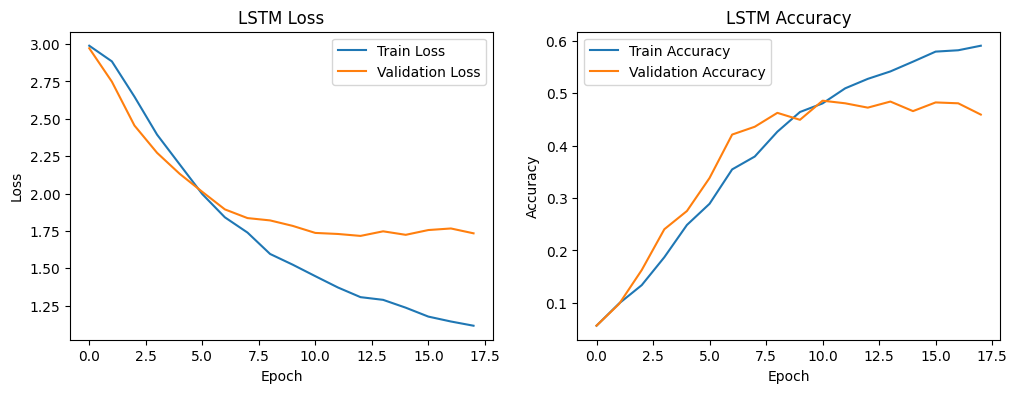

In [ ]:
accuracy_df = pd.DataFrame({'Model': ['LSTM'], 'Accuracy': [lstm_accuracy]})
accuracy_df['Accuracy'] = accuracy_df['Accuracy'].round(4)
print("Model accuracy:")
display(accuracy_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['Accuracy']))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Report (LSTM):


,precision,recall,f1-score,support
category,,,,
0,0.524400,0.290500,0.373900,148.000000
1,0.094600,0.070000,0.080500,100.000000
2,0.327300,0.418600,0.367300,43.000000
3,0.723100,0.810300,0.764200,58.000000
4,0.208300,0.666700,0.317500,45.000000
5,0.571400,0.622200,0.595700,90.000000
6,0.423100,0.105800,0.169200,104.000000
7,0.466700,0.648100,0.542600,54.000000
8,0.464300,0.795900,0.586500,49.000000


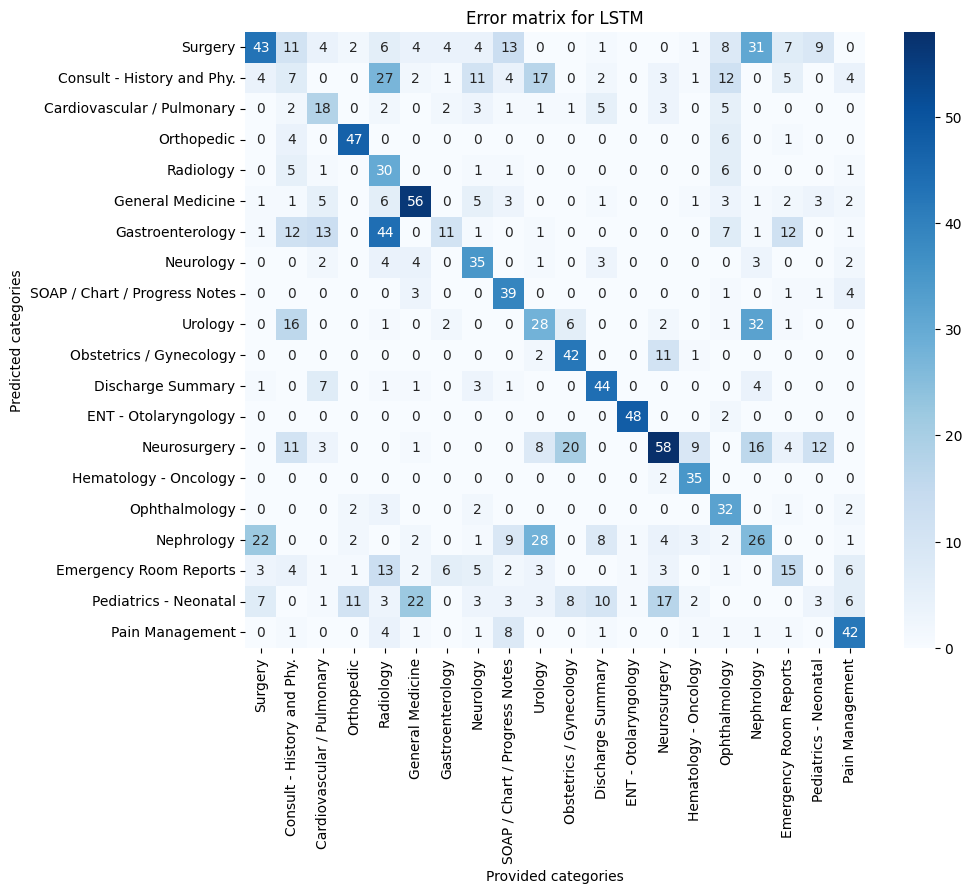

Model LSTM saved


In [ ]:
y_pred_lstm = model_lstm.predict(X_test_pad).argmax(axis=1)
y_true_lstm = y_test

report = classification_report(y_true_lstm, y_pred_lstm, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (LSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for LSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

model_lstm.save('lstm_model.h5')
print("Model LSTM saved")

##### biLSTM

In [ ]:
model_bilstm = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# deal with the class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train_one_hot.argmax(axis=1)
)
class_weight_dict = dict(enumerate(class_weights))

model_bilstm.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=5e-5, mode='min')
history_bilstm = model_bilstm.fit(X_train_pad, y_train_one_hot, epochs=25, batch_size=128,
                             validation_split=0.1, callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict)

loss_bilstm, bilstm_accuracy = model_bilstm.evaluate(X_test_pad, y_test_one_hot, verbose=0)

Epoch 1/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.0640 - loss: 2.9902 - val_accuracy: 0.1824 - val_loss: 2.9748 - learning_rate: 0.0010
Epoch 2/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.1278 - loss: 2.8803 - val_accuracy: 0.1841 - val_loss: 2.6610 - learning_rate: 0.0010
Epoch 3/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.1985 - loss: 2.4956 - val_accuracy: 0.2919 - val_loss: 2.3271 - learning_rate: 0.0010
Epoch 4/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.2544 - loss: 2.1628 - val_accuracy: 0.3665 - val_loss: 2.0613 - learning_rate: 0.0010
Epoch 5/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.3669 - loss: 1.8634 - val_accuracy: 0.4328 - val_loss: 1.8223 - learning_rate: 0.0010
Epoch 6/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.4352 - loss: 1.6150 - val_accuracy: 0.4693 - val_loss: 1.7193 - learning_rate: 0.0010
Epoch 7/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.4877 - loss: 1.4620 - val_acc

Model accuracy:


,Model,Accuracy
0,biLSTM,0.484100


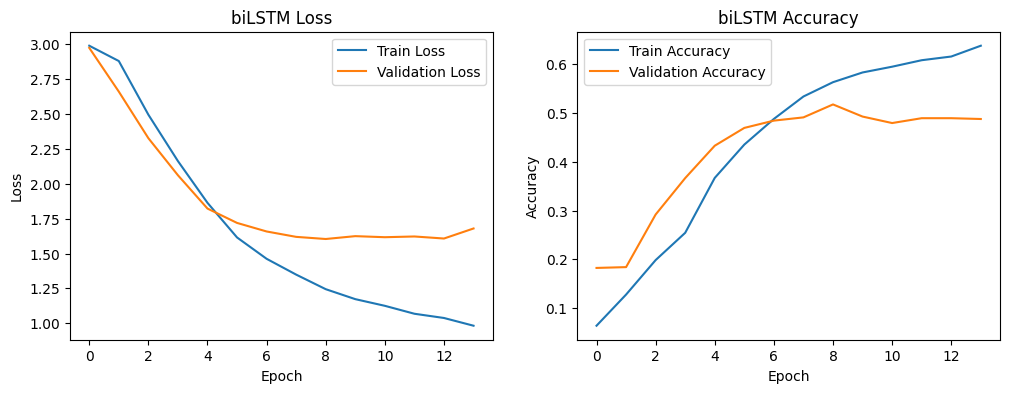

In [ ]:
accuracy_df = pd.DataFrame({'Model': ['biLSTM'], 'Accuracy': [bilstm_accuracy]})
accuracy_df['Accuracy'] = accuracy_df['Accuracy'].round(4)
print("Model accuracy:")
display(accuracy_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['Accuracy']))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_bilstm.history['loss'], label='Train Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.title('biLSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_bilstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('biLSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

Report (biLSTM):


,precision,recall,f1-score,support
category,,,,
0,0.550800,0.439200,0.488700,148.000000
1,0.101400,0.070000,0.082800,100.000000
2,0.320800,0.395300,0.354200,43.000000
3,0.732400,0.896600,0.806200,58.000000
4,0.333300,0.711100,0.453900,45.000000
5,0.578900,0.611100,0.594600,90.000000
6,0.386400,0.163500,0.229700,104.000000
7,0.557400,0.629600,0.591300,54.000000
8,0.500000,0.979600,0.662100,49.000000


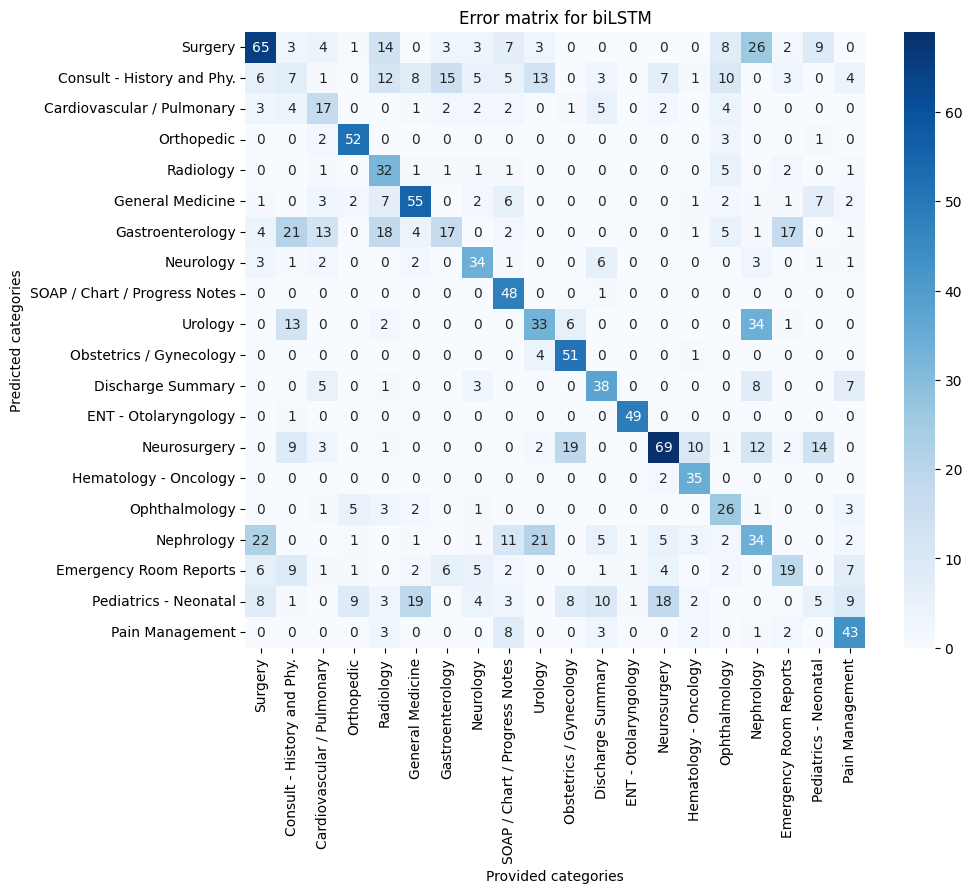

Model biLSTM saved


In [ ]:
y_pred_bilstm = model_bilstm.predict(X_test_pad).argmax(axis=1)
y_true_bilstm = y_test

report = classification_report(y_true_bilstm, y_pred_bilstm, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (biLSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_bilstm, y_pred_bilstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)

plt.title('Error matrix for biLSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

model_bilstm.save('bilstm_model.h5')
print("Model biLSTM saved")

#### Tokenizer + Word2Vec

In [ ]:
EMBED_DIM   = 200
LSTM_HIDDEN  = 200
NUM_FILTERS  = 128
KERNEL_SIZES  = [2, 3, 4]
DROPOUT    = 0.5
MAX_LEN    = 100
BATCH_SIZE   = 64
EPOCHS     = 50
LR       = 1e-3
FOCAL_GAMMA  = 2.0

In [ ]:
X_train_tokens = [text.split() for text in X_train]
X_test_tokens = [text.split() for text in X_test]

# build vocabulary
vocab = build_vocab(X_train_tokens)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# train Word2Vec (skip-gram chosen for this example)
# using a combined corpus for better word embeddings, then restricting to train_vocab
# combined_tokens = X_train_tokens + X_test_tokens # Combine for more robust embeddings
# skipgram_model, _ = train_word2vec(combined_tokens, vector_size=EMBED_DIM, window=5, min_count=2)
skipgram_model, _ = train_word2vec(X_train_tokens, vector_size=EMBED_DIM, window=5, min_count=2)

# build embedding matrix
pretrained_embeddings = build_embedding_matrix(vocab, skipgram_model, vector_size=EMBED_DIM)
print(f"Shape of pretrained_embeddings: {pretrained_embeddings.shape}")

Vocabulary size: 16116
Shape of pretrained_embeddings: (16116, 200)


In [ ]:
# ensure labels are integers
y_train_list = y_train.tolist()
y_test_list = y_test# tokenize
tokenizer_dl = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(X_train)

X_train_seq = tokenizer_dl.texts_to_sequences(X_train)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post').tolist()

# create datasets and dataloaders
train_dataset = TextDataset(X_train_tokens, y_train_list, vocab, max_len=MAX_LEN)
test_dataset = TextDataset(X_test_tokens, y_test_list, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Number of training batches: 95
Number of testing batches: 24


##### CNN + LSTM

In [ ]:
# determine the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ensure num_classes is correctly set
num_classes_actual = len(np.unique(y_train))

model_cnn_lstm_w2v = CNNLSTMModel(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    lstm_hidden=LSTM_HIDDEN,
    num_classes=num_classes_actual,
    dropout=DROPOUT,
    pretrained_embeddings=pretrained_embeddings
).to(device)

print(model_cnn_lstm_w2v)

optimizer = optim.Adam(model_cnn_lstm_w2v.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

Using device: cuda
CNNLSTMModel(
  (embedding): Embedding(16116, 200, padding_idx=0)
  (convs): ModuleList(
    (0): Sequential(
      (0): Conv1d(200, 128, kernel_size=(2,), stride=(1,), padding=(1,))
      (1): ReLU()
    )
    (1): Sequential(
      (0): Conv1d(200, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): ReLU()
    )
    (2): Sequential(
      (0): Conv1d(200, 128, kernel_size=(4,), stride=(1,), padding=(2,))
      (1): ReLU()
    )
  )
  (lstm): LSTM(384, 200, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=200, out_features=20, bias=True)
)


In [ ]:
# training loop
print("Starting training...")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model_cnn_lstm_w2v, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# report final performance
final_train_loss, final_train_acc = evaluate(model_cnn_lstm_w2v, train_loader, criterion, device)
final_test_loss, final_test_acc = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)

print("\n--- Training Finished ---")
print(f"Final Train Accuracy: {final_train_acc:.4f}, Final Train Loss: {final_train_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}, Final Test Loss: {final_test_loss:.4f}")

Starting training...


KeyError: 0

In [ ]:
# get predictions from model
model_cnn_lstm_w2v.eval()  # evaluation mode
y_true_w2v = []
y_pred_w2v = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        logits = model_cnn_lstm_w2v(x_batch)
        predictions = torch.argmax(logits, dim=1).cpu().numpy()
        y_true_w2v.extend(y_batch.cpu().numpy())
        y_pred_w2v.extend(predictions)

# convert to numpy arrays
y_true_w2v = np.array(y_true_w2v)
y_pred_w2v = np.array(y_pred_w2v)

report = classification_report(y_true_w2v, y_pred_w2v, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (Word2Vec + CNN + LSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_w2v, y_pred_w2v)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for Word2Vec + CNN + LSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

### GroupShuffleSplit



In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# set each identical transcription as group
train_idx, test_idx = next(gss.split(df_subset, groups=df_subset['processed_data']))

train_df = df_subset.iloc[train_idx]
test_df  = df_subset.iloc[test_idx]

train_trans = set(train_df['processed_data'])
test_trans  = set(test_df['processed_data'])
print(f"# of rows in train set: {len(train_df)}, # of rows in test set: {len(test_df)}")
print(f"overlap transcription: {len(train_trans & test_trans)}")

X_train, y_train = train_df['processed_data'], train_df['label']
X_test, y_test = test_df['processed_data'], test_df['label']

#### Tokenizer + pad_sequences

In [ ]:
# tokenize
max_words = 20000
max_len = 500
tokenizer_dl = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(X_train)

X_train_seq = tokenizer_dl.texts_to_sequences(X_train)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

In [ ]:
# ensure y_train_one_hot and y_test_one_hot are up-to-date
num_classes = len(y_train.unique())
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)


In [ ]:
# create a stratified validation split from the training data
X_train_sub, X_val_pad, y_train_sub_one_hot, y_val_one_hot = train_test_split(
    X_train_pad, y_train_one_hot, test_size=0.25, random_state=42, stratify=y_train_one_hot
)

print(f"Number of training samples for sub-training: {len(X_train_sub)}")
print(f"Number of validation samples: {len(X_val_pad)}")

##### LSTM

In [ ]:
num_classes = len(y_train.unique())

model_lstm = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    SpatialDropout1D(0.3),
    LSTM(64, return_sequences=True),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# deal with the class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train_one_hot.argmax(axis=1)
)
class_weight_dict = dict(enumerate(class_weights))

model_lstm.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=5e-5, mode='min')
history_lstm = model_lstm.fit(X_train_sub, y_train_sub_one_hot, epochs=25, batch_size=128,
                             validation_data=(X_val_pad, y_val_one_hot), callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict)

loss_lstm, lstm_accuracy = model_lstm.evaluate(X_test_pad, y_test_one_hot, verbose=0)

In [ ]:
accuracy_df = pd.DataFrame({'Model': ['LSTM'], 'Accuracy': [lstm_accuracy]})
accuracy_df['Accuracy'] = accuracy_df['Accuracy'].round(4)
print("Model accuracy:")
display(accuracy_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['Accuracy']))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
y_pred_lstm = model_lstm.predict(X_test_pad).argmax(axis=1)
y_true_lstm = y_test

report = classification_report(y_true_lstm, y_pred_lstm, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (LSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for LSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

model_lstm.save('lstm_model.h5')
print("Model LSTM saved")

##### biLSTM

In [ ]:
model_bilstm = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# deal with the class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train_one_hot.argmax(axis=1)
)
class_weight_dict = dict(enumerate(class_weights))

model_bilstm.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=5e-5, mode='min')
history_bilstm = model_bilstm.fit(X_train_sub, y_train_sub_one_hot, epochs=25, batch_size=128,
                             validation_data=(X_val_pad, y_val_one_hot), callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict)

loss_bilstm, bilstm_accuracy = model_bilstm.evaluate(X_test_pad, y_test_one_hot, verbose=0)

In [ ]:
accuracy_df = pd.DataFrame({'Model': ['biLSTM'], 'Accuracy': [bilstm_accuracy]})
accuracy_df['Accuracy'] = accuracy_df['Accuracy'].round(4)
print("Model accuracy:")
display(accuracy_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['Accuracy']))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_bilstm.history['loss'], label='Train Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.title('biLSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_bilstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('biLSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
y_pred_bilstm = model_bilstm.predict(X_test_pad).argmax(axis=1)
y_true_bilstm = y_test

report = classification_report(y_true_bilstm, y_pred_bilstm, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (biLSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_bilstm, y_pred_bilstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for biLSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

model_lstm.save('bilstm_model.h5')
print("Model biLSTM saved")

#### Tokenizer + Word2Vec

##### CNN + LSTM (BEST)

Text classification based on hybrid CNN-LSTM hybrid model

In [ ]:
X_train_tokens = [text.split() for text in X_train]
X_test_tokens = [text.split() for text in X_test]

# build vocabulary
vocab = build_vocab(X_train_tokens)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# train Word2Vec (skip-gram chosen for this example)
# using a combined corpus for better word embeddings, then restricting to train_vocab
# combined_tokens = X_train_tokens + X_test_tokens # Combine for more robust embeddings
# skipgram_model, _ = train_word2vec(combined_tokens, vector_size=EMBED_DIM, window=5, min_count=2)
skipgram_model, _ = train_word2vec(X_train_tokens, vector_size=EMBED_DIM, window=5, min_count=2)

# build embedding matrix
pretrained_embeddings = build_embedding_matrix(vocab, skipgram_model, vector_size=EMBED_DIM)
print(f"Shape of pretrained_embeddings: {pretrained_embeddings.shape}")

In [ ]:
y_train_list = y_train.tolist()
y_test_list = y_test.tolist()

train_dataset = TextDataset(X_train_tokens, y_train_list, vocab, max_len=MAX_LEN)
test_dataset = TextDataset(X_test_tokens, y_test_list, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

In [ ]:
# determine the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ensure num_classes is correctly set
num_classes_actual = len(np.unique(y_train))

model_cnn_lstm_w2v = CNNLSTMModel(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    lstm_hidden=LSTM_HIDDEN,
    num_classes=num_classes_actual,
    dropout=DROPOUT,
    pretrained_embeddings=pretrained_embeddings
).to(device)

print(model_cnn_lstm_w2v)

optimizer = optim.Adam(model_cnn_lstm_w2v.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

In [ ]:
# training
print("Starting training...")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model_cnn_lstm_w2v, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# report final performance
final_train_loss, final_train_acc = evaluate(model_cnn_lstm_w2v, train_loader, criterion, device)
final_test_loss, final_test_acc = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)

print("\n--- Training Finished ---")
print(f"Final Train Accuracy: {final_train_acc:.4f}, Final Train Loss: {final_train_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}, Final Test Loss: {final_test_loss:.4f}")

In [ ]:
# get predictions from model
model_cnn_lstm_w2v.eval()  # evaluation mode
y_true_w2v = []
y_pred_w2v = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        logits = model_cnn_lstm_w2v(x_batch)
        predictions = torch.argmax(logits, dim=1).cpu().numpy()
        y_true_w2v.extend(y_batch.cpu().numpy())
        y_pred_w2v.extend(predictions)

# convert to numpy arrays
y_true_w2v = np.array(y_true_w2v)
y_pred_w2v = np.array(y_pred_w2v)

report = classification_report(y_true_w2v, y_pred_w2v, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (Word2Vec + CNN + LSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_w2v, y_pred_w2v)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for Word2Vec + CNN + LSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

In [ ]:
# save CNN-LSTM model as .pkl file
from google.colab import files
import pickle

with open("CNN_LSTM_mtsample_augmented.pkl", "wb") as f:
    pickle.dump(model_cnn_lstm_w2v, f)

files.download("CNN_LSTM_mtsample_augmented.pkl")

###

## Data Augmentation 2 (15 categories)

Use augmented_mtsamples.csv

In [ ]:
df = pd.read_csv("augmented_mtsamples.csv")

In [ ]:
df_subset = df[['processed_data', 'label']].copy()

In [ ]:
df_subset.dropna(subset=['processed_data'], inplace=True)

In [ ]:
df_subset.head()

,processed_data,label
0,mode atrial enlargement atrial diameter cm siz...,0
1,ventricular cavity size wall thickness appear ...,0
2,echocardiogram multiple view heart great vesse...,0
3,description cardiac chamber size ventricular s...,0
4,study mild aortic stenosis widely calcify mini...,0


In [ ]:
max_words = 20000
max_len = 500

In [ ]:
classes = [
    'Cardiovascular / Pulmonary',
    'ENT - Otolaryngology',
    'Emergency Room Reports',
    'Gastroenterology',
    'General Medicine',
    'Hematology - Oncology',
    'Nephrology',
    'Neurology',
    'Neurosurgery',
    'Obstetrics / Gynecology',
    'Ophthalmology',
    'Orthopedic',
    'Pain Management',
    'Pediatrics - Neonatal',
    'Urology'
]

In [ ]:
EMBED_DIM   = 200
LSTM_HIDDEN  = 200
NUM_FILTERS  = 128
KERNEL_SIZES  = [2, 3, 4]
DROPOUT    = 0.5
MAX_LEN    = 100
BATCH_SIZE   = 64
EPOCHS     = 50
LR       = 1e-3
FOCAL_GAMMA  = 2.0

### train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df_subset['processed_data'],
    df_subset['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_subset['label']  # make sure both train and test set have data of all classes
)

In [ ]:
X_train.nunique() / X_train.shape[0]

0.7999080036798528

In [ ]:
X_test.nunique() / X_test.shape[0]

0.9384191176470589

#### Tokenizer + Word2Vec

In [ ]:
X_train_tokens = [text.split() for text in X_train]
X_test_tokens = [text.split() for text in X_test]

# build vocabulary
vocab = build_vocab(X_train_tokens)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# train Word2Vec (skip-gram chosen for this example)
# using a combined corpus for better word embeddings, then restricting to train_vocab
# combined_tokens = X_train_tokens + X_test_tokens # Combine for more robust embeddings
# skipgram_model, _ = train_word2vec(combined_tokens, vector_size=EMBED_DIM, window=5, min_count=2)
skipgram_model, _ = train_word2vec(X_train_tokens, vector_size=EMBED_DIM, window=5, min_count=2)

# build embedding matrix
pretrained_embeddings = build_embedding_matrix(vocab, skipgram_model, vector_size=EMBED_DIM)
print(f"Shape of pretrained_embeddings: {pretrained_embeddings.shape}")

Vocabulary size: 14464
Shape of pretrained_embeddings: (14464, 200)


In [ ]:
# ensure labels are integers
y_train_list = y_train.tolist()
y_test_list = y_test.tolist()

# create datasets and dataloaders
train_dataset = TextDataset(X_train_tokens, y_train_list, vocab, max_len=MAX_LEN)
test_dataset = TextDataset(X_test_tokens, y_test_list, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Number of training batches: 68
Number of testing batches: 17


##### CNN + LSTM

In [ ]:
# determine the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ensure num_classes is correctly set
num_classes_actual = len(np.unique(y_train))

model_cnn_lstm_w2v = CNNLSTMModel(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    lstm_hidden=LSTM_HIDDEN,
    num_classes=num_classes_actual,
    dropout=DROPOUT,
    pretrained_embeddings=pretrained_embeddings
).to(device)

print(model_cnn_lstm_w2v)

optimizer = optim.Adam(model_cnn_lstm_w2v.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

Using device: cuda
CNNLSTMModel(
  (embedding): Embedding(14464, 200, padding_idx=0)
  (convs): ModuleList(
    (0): Sequential(
      (0): Conv1d(200, 128, kernel_size=(2,), stride=(1,), padding=(1,))
      (1): ReLU()
    )
    (1): Sequential(
      (0): Conv1d(200, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): ReLU()
    )
    (2): Sequential(
      (0): Conv1d(200, 128, kernel_size=(4,), stride=(1,), padding=(2,))
      (1): ReLU()
    )
  )
  (lstm): LSTM(384, 200, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=200, out_features=15, bias=True)
)


In [ ]:
# training loop
print("Starting training...")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model_cnn_lstm_w2v, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# report final performance
final_train_loss, final_train_acc = evaluate(model_cnn_lstm_w2v, train_loader, criterion, device)
final_test_loss, final_test_acc = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)

print("\n--- Training Finished ---")
print(f"Final Train Accuracy: {final_train_acc:.4f}, Final Train Loss: {final_train_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}, Final Test Loss: {final_test_loss:.4f}")

Starting training...
Epoch 1/50 | Train Loss: 2.2175, Train Acc: 0.3057 | Val Loss: 1.4605, Val Acc: 0.5542
Epoch 2/50 | Train Loss: 1.0254, Train Acc: 0.6838 | Val Loss: 0.9013, Val Acc: 0.7031
Epoch 3/50 | Train Loss: 0.6376, Train Acc: 0.7755 | Val Loss: 0.7458, Val Acc: 0.7261
Epoch 4/50 | Train Loss: 0.4759, Train Acc: 0.8231 | Val Loss: 0.6547, Val Acc: 0.7390
Epoch 5/50 | Train Loss: 0.4038, Train Acc: 0.8425 | Val Loss: 0.6691, Val Acc: 0.7463
Epoch 6/50 | Train Loss: 0.3700, Train Acc: 0.8519 | Val Loss: 0.6815, Val Acc: 0.7574
Epoch 7/50 | Train Loss: 0.3588, Train Acc: 0.8526 | Val Loss: 0.6987, Val Acc: 0.7757
Epoch 8/50 | Train Loss: 0.3348, Train Acc: 0.8569 | Val Loss: 0.6959, Val Acc: 0.7417
Epoch 9/50 | Train Loss: 0.3318, Train Acc: 0.8586 | Val Loss: 0.6898, Val Acc: 0.7546
Epoch 10/50 | Train Loss: 0.3157, Train Acc: 0.8625 | Val Loss: 0.7069, Val Acc: 0.7500
Epoch 11/50 | Train Loss: 0.3162, Train Acc: 0.8641 | Val Loss: 0.7121, Val Acc: 0.7500
Epoch 12/50 | Train 


Report (Word2Vec + CNN + LSTM):


,precision,recall,f1-score,support
category,,,,
0,0.798700,0.831100,0.814600,148.000000
1,0.886800,0.810300,0.846800,58.000000
2,0.420000,0.466700,0.442100,45.000000
3,0.795500,0.777800,0.786500,90.000000
4,0.800000,0.576900,0.670400,104.000000
5,0.688500,0.777800,0.730400,54.000000
6,0.704900,0.877600,0.781800,49.000000
7,0.684800,0.707900,0.696100,89.000000
8,0.610200,0.642900,0.626100,56.000000


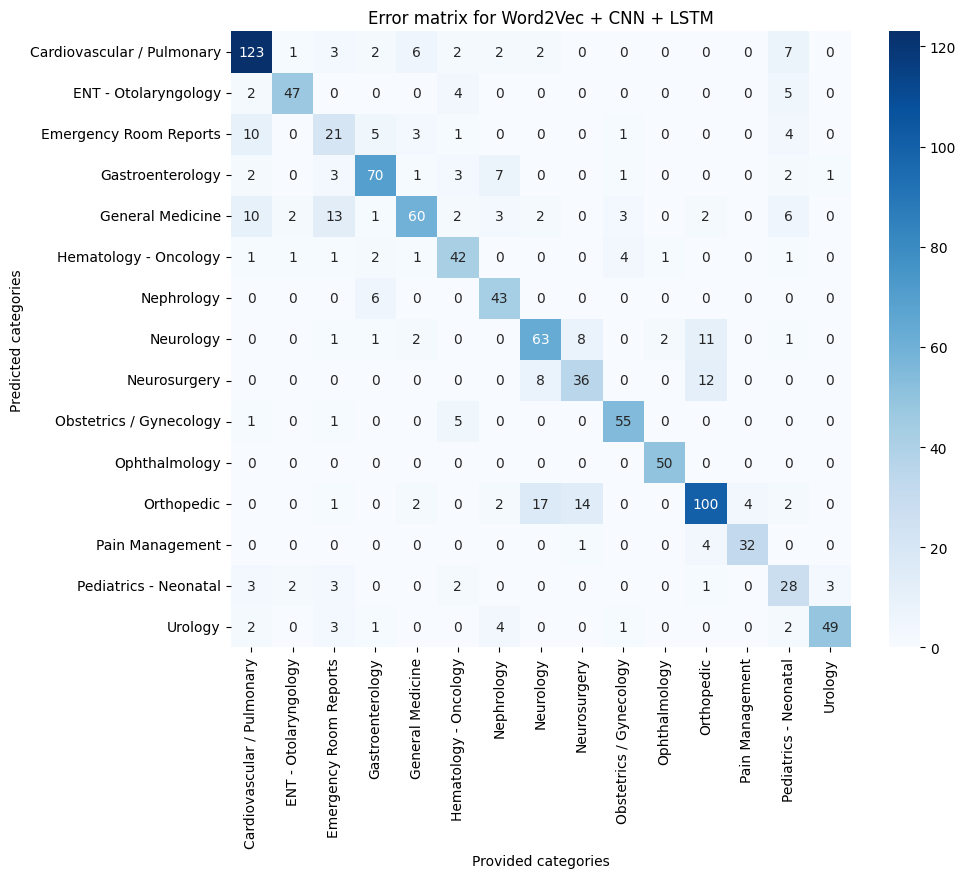

In [ ]:
# get predictions from model
model_cnn_lstm_w2v.eval()  # evaluation mode
y_true_w2v = []
y_pred_w2v = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        logits = model_cnn_lstm_w2v(x_batch)
        predictions = torch.argmax(logits, dim=1).cpu().numpy()
        y_true_w2v.extend(y_batch.cpu().numpy())
        y_pred_w2v.extend(predictions)

# convert to numpy arrays
y_true_w2v = np.array(y_true_w2v)
y_pred_w2v = np.array(y_pred_w2v)

report = classification_report(y_true_w2v, y_pred_w2v, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (Word2Vec + CNN + LSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_w2v, y_pred_w2v)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for Word2Vec + CNN + LSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

### GroupShuffleSplit


In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# set each identical transcription as group
train_idx, test_idx = next(gss.split(df_subset, groups=df_subset['processed_data']))

train_df = df_subset.iloc[train_idx]
test_df  = df_subset.iloc[test_idx]


train_trans = set(train_df['processed_data'])
test_trans  = set(test_df['processed_data'])
print(f"# of rows in train set: {len(train_df)}, # of rows in test set: {len(test_df)}")
print(f"overlap transcription: {len(train_trans & test_trans)}")

X_train, y_train = train_df['processed_data'], train_df['label']
X_test, y_test = test_df['processed_data'], test_df['label']

# of rows in train set: 4327, # of rows in test set: 1109
overlap transcription: 0


In [ ]:
X_train.nunique() / X_train.shape[0]

0.7608042523688467

In [ ]:
X_test.nunique() / X_test.shape[0]

0.7430117222723174

#### Tokenizer + Word2Vec

##### CNN + LSTM (BEST)

Text classification based on hybrid CNN-LSTM hybrid model

In [ ]:
X_train_tokens = [text.split() for text in X_train]
X_test_tokens = [text.split() for text in X_test]

# build vocabulary
vocab = build_vocab(X_train_tokens)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# train Word2Vec (skip-gram here)
# using a combined corpus for better word embeddings, then restricting to train_vocab
# combined_tokens = X_train_tokens + X_test_tokens # Combine for more robust embeddings
# skipgram_model, _ = train_word2vec(combined_tokens, vector_size=EMBED_DIM, window=5, min_count=2)
skipgram_model, _ = train_word2vec(X_train_tokens, vector_size=EMBED_DIM, window=5, min_count=2)

# build embedding matrix
pretrained_embeddings = build_embedding_matrix(vocab, skipgram_model, vector_size=EMBED_DIM)
# pretrained_embeddings = build_embedding_matrix(vocab, CBOW, vector_size=EMBED_DIM)
print(f"Shape of pretrained_embeddings: {pretrained_embeddings.shape}")

Vocabulary size: 14349
Shape of pretrained_embeddings: (14349, 200)


In [ ]:
y_train_list = y_train.tolist()
y_test_list = y_test.tolist()

train_dataset = TextDataset(X_train_tokens, y_train_list, vocab, max_len=MAX_LEN)
test_dataset = TextDataset(X_test_tokens, y_test_list, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Number of training batches: 68
Number of testing batches: 18


In [ ]:
classes_arr  = np.unique(y_train_list)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes_arr,
    y=y_train_list
)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ensure num_classes is correctly set
num_classes_actual = len(np.unique(y_train))

model_cnn_lstm_w2v = CNNLSTMModel(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    lstm_hidden=LSTM_HIDDEN,
    num_classes=num_classes_actual,
    dropout=DROPOUT,
    pretrained_embeddings=pretrained_embeddings
).to(device)

print(model_cnn_lstm_w2v)

optimizer = optim.Adam(model_cnn_lstm_w2v.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

Using device: cuda
CNNLSTMModel(
  (embedding): Embedding(14349, 200, padding_idx=0)
  (convs): ModuleList(
    (0): Sequential(
      (0): Conv1d(200, 128, kernel_size=(2,), stride=(1,), padding=(1,))
      (1): ReLU()
    )
    (1): Sequential(
      (0): Conv1d(200, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): ReLU()
    )
    (2): Sequential(
      (0): Conv1d(200, 128, kernel_size=(4,), stride=(1,), padding=(2,))
      (1): ReLU()
    )
  )
  (lstm): LSTM(384, 200, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=200, out_features=15, bias=True)
)


In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Start training（CNN-LSTM）...")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model_cnn_lstm_w2v, train_loader, optimizer, criterion, device)
    val_loss,   val_acc = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

_, accuracy = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)
print(f"\nFinal focal accuracy: {accuracy:.4f}")

Start training（CNN-LSTM）...
Epoch 01/50 | Train Loss: 2.2159, Train Acc: 0.3159 | Val Loss: 1.5288, Val Acc: 0.5041
Epoch 02/50 | Train Loss: 1.0957, Train Acc: 0.6598 | Val Loss: 0.9177, Val Acc: 0.7060
Epoch 03/50 | Train Loss: 0.6757, Train Acc: 0.7698 | Val Loss: 0.6872, Val Acc: 0.7538
Epoch 04/50 | Train Loss: 0.4924, Train Acc: 0.8167 | Val Loss: 0.6086, Val Acc: 0.7800
Epoch 05/50 | Train Loss: 0.4319, Train Acc: 0.8297 | Val Loss: 0.5584, Val Acc: 0.7989
Epoch 06/50 | Train Loss: 0.3921, Train Acc: 0.8343 | Val Loss: 0.4988, Val Acc: 0.8034
Epoch 07/50 | Train Loss: 0.3680, Train Acc: 0.8378 | Val Loss: 0.4818, Val Acc: 0.8025
Epoch 08/50 | Train Loss: 0.3625, Train Acc: 0.8403 | Val Loss: 0.5249, Val Acc: 0.7953
Epoch 09/50 | Train Loss: 0.3595, Train Acc: 0.8442 | Val Loss: 0.4787, Val Acc: 0.8124
Epoch 10/50 | Train Loss: 0.3479, Train Acc: 0.8426 | Val Loss: 0.4447, Val Acc: 0.8088
Epoch 11/50 | Train Loss: 0.3342, Train Acc: 0.8526 | Val Loss: 0.4624, Val Acc: 0.8079
Epoc

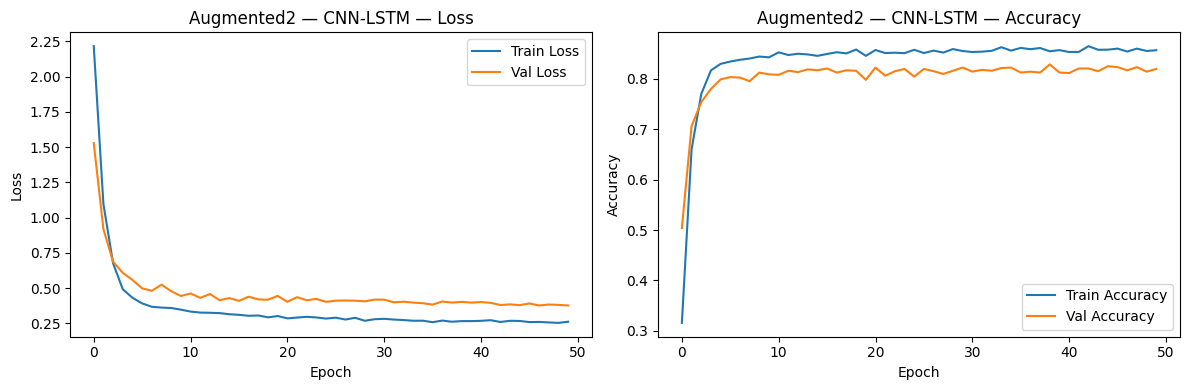

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Augmented2 — CNN-LSTM — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Accuracy')
axes[1].plot(history['val_acc'],   label='Val Accuracy')
axes[1].set_title('Augmented2 — CNN-LSTM — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


Report (CNNLSTM):


,precision,recall,f1-score,support
category,,,,
0,0.919700,0.881100,0.900000,143.000000
1,0.866700,0.866700,0.866700,45.000000
2,0.545500,0.714300,0.618600,42.000000
3,0.771400,0.861700,0.814100,94.000000
4,0.902400,0.747500,0.817700,99.000000
5,0.644100,0.844400,0.730800,45.000000
6,0.803600,0.625000,0.703100,72.000000
7,0.805800,0.830000,0.817700,100.000000
8,0.638600,0.946400,0.762600,56.000000


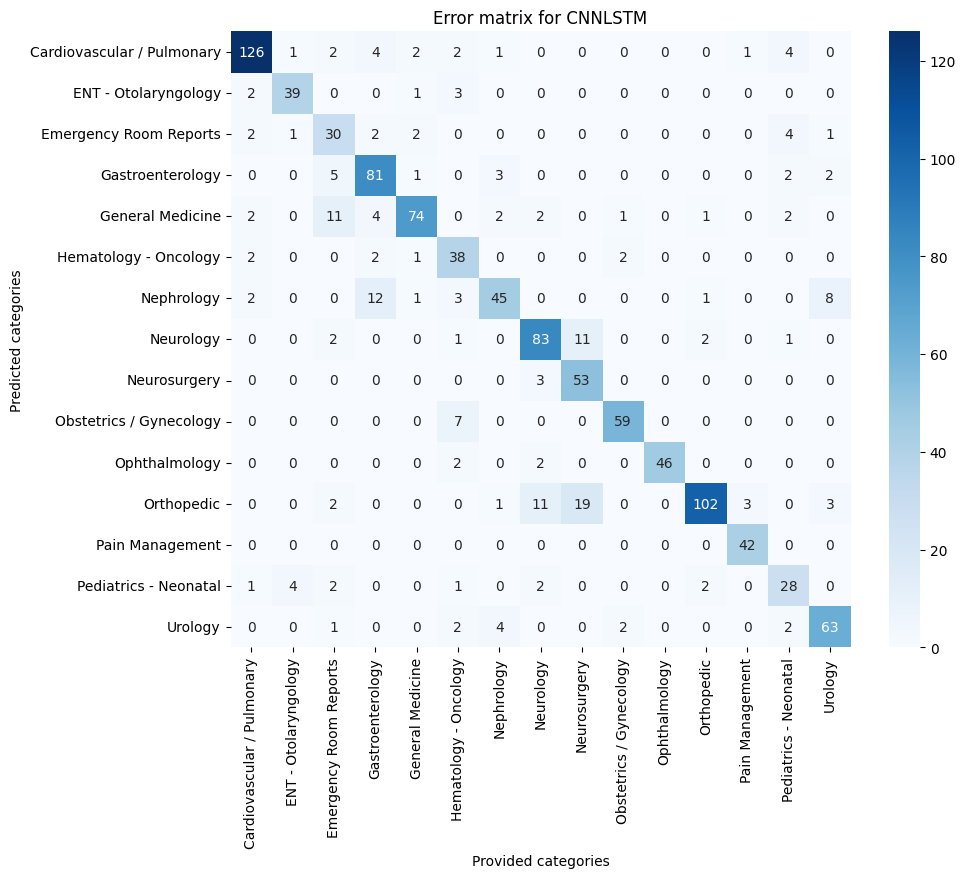

In [ ]:
# get predictions from model
model_cnn_lstm_w2v.eval()  # evaluation mode
y_true_w2v = []
y_pred_w2v = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        logits = model_cnn_lstm_w2v(x_batch)
        predictions = torch.argmax(logits, dim=1).cpu().numpy()
        y_true_w2v.extend(y_batch.cpu().numpy())
        y_pred_w2v.extend(predictions)

# convert to numpy arrays
y_true_w2v = np.array(y_true_w2v)
y_pred_w2v = np.array(y_pred_w2v)

report = classification_report(y_true_w2v, y_pred_w2v, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (CNNLSTM):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_w2v, y_pred_w2v)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, p)
# sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues')
plt.title('Error matrix for CNNLSTM')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

In [ ]:
# save CNN-LSTM model as .pkl file
from google.colab import files
import pickle

with open("CNN_LSTM_augmented_mtsample.pkl", "wb") as f:
    pickle.dump(model_cnn_lstm_w2v, f)

files.download("CNN_LSTM_augmented_mtsample.pkl")

## Data Augmentation 3

**bionlp**


In [ ]:
nlp = spacy.load('en_core_sci_md')

In [ ]:
def process_text(text):
    wordlist=[]
    doc = nlp(text)
    for ent in doc.ents:
        wordlist.append(ent.text)
    return ' '.join(wordlist)

In [ ]:
def process_text_v2(text):
    doc = nlp(text)
    entities = [ent.text for ent in doc.ents]
    # duplicate the entities at the end of the original data top add weights for the entities
    return text + ' ' + ' '.join(entities)

In [ ]:
# df_subset['processed_data'] = df_subset['processed_data'].apply(process_text)

In [ ]:
df_subset['processed_data'] = df_subset['processed_data'].apply(process_text_v2)

KeyboardInterrupt: 

### train_test_split + Focal Loss

In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    - gamma: focas parameter（recommend: 1~3，default: 2）
    - alpha: class weights，input: tensor，shape=(num_classes,)
    """
    def __init__(self, gamma: float = 2.0, alpha: torch.Tensor = None, reduction: str = 'mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha  # (num_classes,) or None
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # logits: (batch, num_classes), targets: (batch,)
        ce_loss = F.cross_entropy(logits, targets, reduction='none')   # (batch,)
        pt = torch.exp(-ce_loss)                      # (batch,)
        focal_weight = (1.0 - pt) ** self.gamma            # (batch,)

        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[targets]      # (batch,)
            focal_weight = alpha_t * focal_weight

        loss = focal_weight * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df_subset['processed_data'],
    df_subset['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_subset['label']  # make sure both train and test set have data of all classes
)

#### Tokenizer + Word2Vec

In [ ]:
X_train_tokens = [text.split() for text in X_train]
X_test_tokens = [text.split() for text in X_test]

# build vocabulary
vocab = build_vocab(X_train_tokens)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# train Word2Vec (skip-gram chosen for this example)
# using a combined corpus for better word embeddings, then restricting to train_vocab
# combined_tokens = X_train_tokens + X_test_tokens # Combine for more robust embeddings
# skipgram_model, _ = train_word2vec(combined_tokens, vector_size=EMBED_DIM, window=5, min_count=2)
skipgram_model, _ = train_word2vec(X_train_tokens, vector_size=EMBED_DIM, window=5, min_count=2)

# build embedding matrix
pretrained_embeddings = build_embedding_matrix(vocab, skipgram_model, vector_size=EMBED_DIM)
print(f"Shape of pretrained_embeddings: {pretrained_embeddings.shape}")

In [ ]:
# ensure labels are integers
y_train_list = y_train.tolist()
y_test_list = y_test.tolist()

# create datasets and dataloaders
train_dataset = TextDataset(X_train_tokens, y_train_list, vocab, max_len=MAX_LEN)
test_dataset = TextDataset(X_test_tokens, y_test_list, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

##### CNN + LSTM

In [ ]:
classes_arr  = np.unique(y_train_list)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes_arr,
    y=y_train_list
)

In [ ]:
alpha_tensor = torch.tensor(class_weights, dtype=torch.float32)

# extra weight for the worst classes
# alpha_tensor[[2, 13]] *= 1.5

In [ ]:
# determine the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ensure num_classes is correctly set
num_classes_actual = len(np.unique(y_train))

model_cnn_lstm_w2v = CNNLSTMModel(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    lstm_hidden=LSTM_HIDDEN,
    num_classes=num_classes_actual,
    dropout=DROPOUT,
    pretrained_embeddings=pretrained_embeddings
).to(device)

print(model_cnn_lstm_w2v)

optimizer = optim.Adam(model_cnn_lstm_w2v.parameters(), lr=LR)
criterion  = FocalLoss(gamma=FOCAL_GAMMA, alpha=alpha_tensor)

In [ ]:
# training loop
print("Starting training...")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model_cnn_lstm_w2v, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# report final performance
final_train_loss, final_train_acc = evaluate(model_cnn_lstm_w2v, train_loader, criterion, device)
final_test_loss, final_test_acc = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)

print("\n--- Training Finished ---")
print(f"Final Train Accuracy: {final_train_acc:.4f}, Final Train Loss: {final_train_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}, Final Test Loss: {final_test_loss:.4f}")

In [ ]:
# get predictions from model
model_cnn_lstm_w2v.eval()  # evaluation mode
y_true_w2v = []
y_pred_w2v = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        logits = model_cnn_lstm_w2v(x_batch)
        predictions = torch.argmax(logits, dim=1).cpu().numpy()
        y_true_w2v.extend(y_batch.cpu().numpy())
        y_pred_w2v.extend(predictions)

# convert to numpy arrays
y_true_w2v = np.array(y_true_w2v)
y_pred_w2v = np.array(y_pred_w2v)

report = classification_report(y_true_w2v, y_pred_w2v, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (Word2Vec + CNN + LSTM + Focal Loss):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_w2v, y_pred_w2v)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for Word2Vec + CNN + LSTM + Focal Loss')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

### GroupShuffleSplit + Focal Loss

In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# set each identical transcription as group
train_idx, test_idx = next(gss.split(df_subset, groups=df_subset['processed_data']))

train_df = df_subset.iloc[train_idx]
test_df  = df_subset.iloc[test_idx]

train_trans = set(train_df['processed_data'])
test_trans  = set(test_df['processed_data'])
print(f"# of rows in train set: {len(train_df)}, # of rows in test set: {len(test_df)}")
print(f"overlap transcription: {len(train_trans & test_trans)}")

X_train, y_train = train_df['processed_data'], train_df['label']
X_test, y_test = test_df['processed_data'], test_df['label']

#### Tokenizer + Word2Vec


##### CNN + LSTM

Text classification based on hybrid CNN-LSTM hybrid model

In [ ]:
X_train_tokens = [text.split() for text in X_train]
X_test_tokens = [text.split() for text in X_test]

# build vocabulary
vocab = build_vocab(X_train_tokens)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# train Word2Vec (skip-gram here)
# using a combined corpus for better word embeddings, then restricting to train_vocab
# combined_tokens = X_train_tokens + X_test_tokens # Combine for more robust embeddings
# skipgram_model, _ = train_word2vec(combined_tokens, vector_size=EMBED_DIM, window=5, min_count=2)
skipgram_model, _ = train_word2vec(X_train_tokens, vector_size=EMBED_DIM, window=5, min_count=2)

# build embedding matrix
pretrained_embeddings = build_embedding_matrix(vocab, skipgram_model, vector_size=EMBED_DIM)
# pretrained_embeddings = build_embedding_matrix(vocab, CBOW, vector_size=EMBED_DIM)
print(f"Shape of pretrained_embeddings: {pretrained_embeddings.shape}")

In [ ]:
y_train_list = y_train.tolist()
y_test_list = y_test.tolist()

train_dataset = TextDataset(X_train_tokens, y_train_list, vocab, max_len=MAX_LEN)
test_dataset = TextDataset(X_test_tokens, y_test_list, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

In [ ]:
classes_arr  = np.unique(y_train_list)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes_arr,
    y=y_train_list
)

In [ ]:
alpha_tensor = torch.tensor(class_weights, dtype=torch.float32)

# extra weight for the worst classes
# alpha_tensor[[2, 13]] *= 1.5

In [ ]:
print("Focal Loss alpha (class weights):")
for cls, w in zip(classes_arr, class_weights):
    print(f"  class {cls}: {w:.4f}")

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ensure num_classes is correctly set
num_classes_actual = len(np.unique(y_train))

model_cnn_lstm_w2v = CNNLSTMModel(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    lstm_hidden=LSTM_HIDDEN,
    num_classes=num_classes_actual,
    dropout=DROPOUT,
    pretrained_embeddings=pretrained_embeddings
).to(device)

print(model_cnn_lstm_w2v)

optimizer = optim.Adam(model_cnn_lstm_w2v.parameters(), lr=LR)
criterion  = FocalLoss(gamma=FOCAL_GAMMA, alpha=alpha_tensor)

In [ ]:
history_focal = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Start training（Focal Loss + Word2Vec + CNN-LSTM）...")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model_cnn_lstm_w2v, train_loader, optimizer, criterion, device)
    val_loss,   val_acc = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)

    history_focal['train_loss'].append(train_loss)
    history_focal['train_acc'].append(train_acc)
    history_focal['val_loss'].append(val_loss)
    history_focal['val_acc'].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

_, focal_accuracy = evaluate(model_cnn_lstm_w2v, test_loader, criterion, device)
print(f"\nFinal focal accuracy: {focal_accuracy:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_focal['train_loss'], label='Train Loss')
axes[0].plot(history_focal['val_loss'],   label='Val Loss')
axes[0].set_title('Focal Loss + CNN-LSTM — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_focal['train_acc'], label='Train Accuracy')
axes[1].plot(history_focal['val_acc'],   label='Val Accuracy')
axes[1].set_title('Focal Loss + CNN-LSTM — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# get predictions from model
model_cnn_lstm_w2v.eval()  # evaluation mode
y_true_w2v = []
y_pred_w2v = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        logits = model_cnn_lstm_w2v(x_batch)
        predictions = torch.argmax(logits, dim=1).cpu().numpy()
        y_true_w2v.extend(y_batch.cpu().numpy())
        y_pred_w2v.extend(predictions)

# convert to numpy arrays
y_true_w2v = np.array(y_true_w2v)
y_pred_w2v = np.array(y_pred_w2v)

report = classification_report(y_true_w2v, y_pred_w2v, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
report_df.index.name = 'category'
print("\nReport (CNNLSTM + Focal Loss):")
display(report_df.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '5px')]}
        ])
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_true_w2v, y_pred_w2v)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Error matrix for CNNLSTM + Focal Loss + Lemmatization + en_core_sci_md')
plt.xlabel('Provided categories')
plt.ylabel('Predicted categories')
plt.show()

# File Export for demo

In [ ]:
from google.colab import files
import pickle

cnn_lstm = {
    "model": model_cnn_lstm_w2v,
    "vocab": vocab,
    "x_test": X_test_tokens,
    "y_test": y_test_list,
    "label_encoder" : classes

}

torch.save(cnn_lstm, "CNN_LSTM_augmented_mtsample.pkl")

files.download("CNN_LSTM_augmented_mtsample.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>